In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

%matplotlib inline
sns.set(rc={'figure.figsize':(10,6)})

In [61]:
import io
from pathlib import Path
import pandas as pd


def load_fifa_data():
    """Load the FIFA dataset reproducibly, with Colab upload only as a fallback."""
    candidate_paths = [
        "Fifa.csv",
        "/content/Fifa.csv",
        r"C:\Users\zxgam\Downloads\Fifa.csv",
    ]

    for path in candidate_paths:
        if Path(path).exists():
            print(f"Loaded dataset from: {path}")
            return pd.read_csv(path)

    try:
        from google.colab import files

        uploaded = files.upload()
        file_name = list(uploaded.keys())[0]
        print(f"Loaded uploaded dataset: {file_name}")
        return pd.read_csv(io.BytesIO(uploaded[file_name]))
    except Exception as exc:
        raise FileNotFoundError(
            "Fifa.csv was not found. Place it beside the notebook or upload it in Colab."
        ) from exc


df = load_fifa_data()
df.head()

Loaded dataset from: Fifa.csv


,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640


In [ ]:
missing_vals = df.isnull().sum()

print("Missing values per column:")
print(missing_vals)

Missing values per column:
Name                 0
Country              0
Position             0
Age                  0
Overall_Rating       0
Future Potential     0
Team                 0
Value Per M$         0
Total_Stats Score    0
dtype: int64


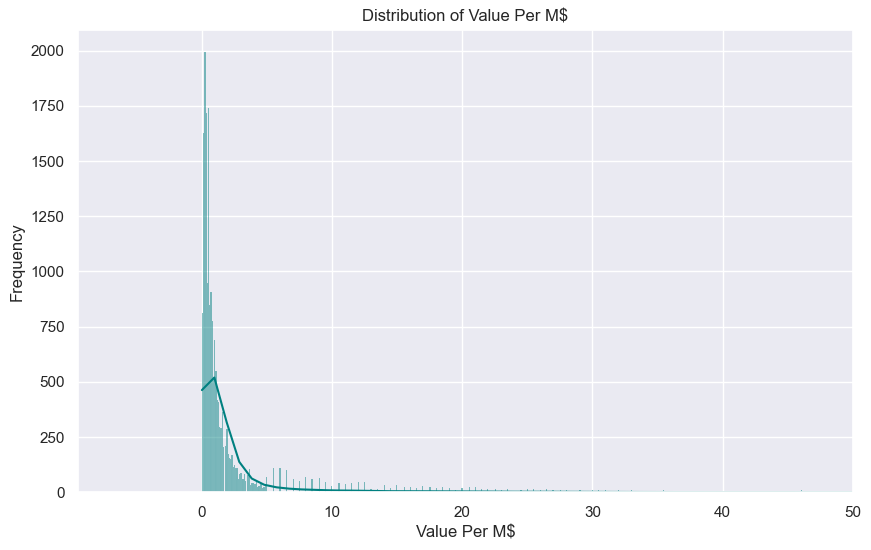

Skewness of Value Per M$: 7.98
The distribution is highly skewed to the right (positive).


In [63]:
# Visualize the distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Value Per M$'], kde=True, color='teal')
plt.title('Distribution of Value Per M$')
plt.xlabel('Value Per M$')
plt.ylabel('Frequency')
plt.xlim(right=50)
plt.show()

# Compute skewness
val_skewness = df['Value Per M$'].skew()
print(f"Skewness of Value Per M$: {val_skewness:.2f}")

# Interpretation
if abs(val_skewness) < 0.5:
    print("The distribution is approximately symmetric (Normal).")
else:
    direction = "right (positive)" if val_skewness > 0 else "left (negative)"
    print(f"The distribution is highly skewed to the {direction}.")

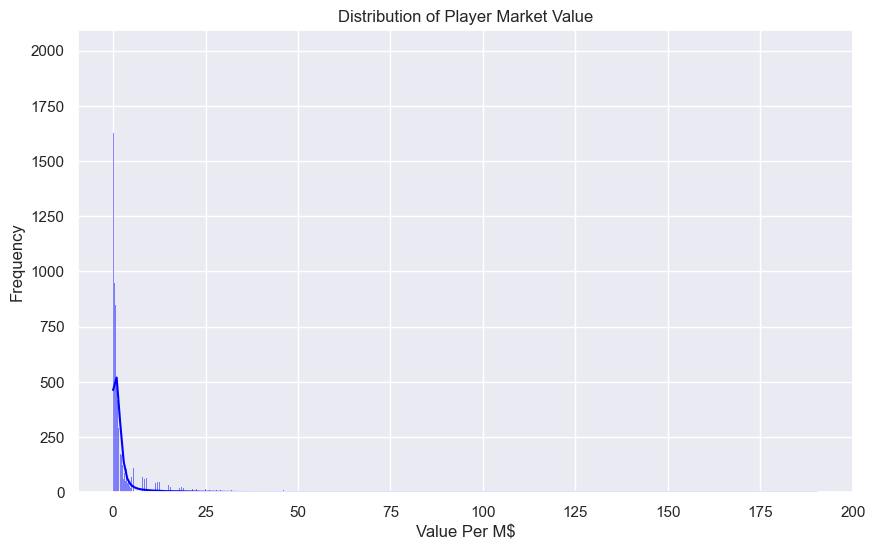

Skewness of Value Per M$: 7.98


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Value Per M$'], kde=True, color='blue')
plt.title('Distribution of Player Market Value')
plt.xlabel('Value Per M$')
plt.ylabel('Frequency')
plt.show()

market_skewness = df['Value Per M$'].skew()
print(f"Skewness of Value Per M$: {market_skewness:.2f}")

In [ ]:
numeric_cols = df.select_dtypes(include=['float64', 'int64'])

correlation_matrix = numeric_cols.corr()
value_correlation = correlation_matrix['Value Per M$'].sort_values(ascending=False)

print("Correlation of features with Market Value:")
print(value_correlation)

Correlation of features with Market Value:
Value Per M$         1.000000
Overall_Rating       0.560648
Future Potential     0.500964
Total_Stats Score    0.385062
Age                  0.142276
Name: Value Per M$, dtype: float64


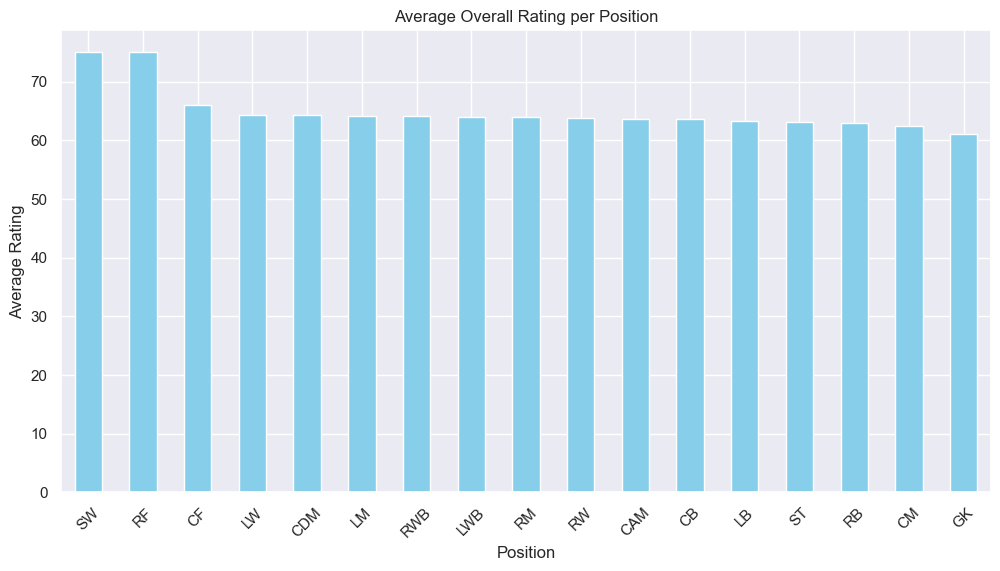

Average Overall Rating per Position:
Position
SW     75.000000
RF     75.000000
CF     66.042857
LW     64.345979
CDM    64.234168
LM     64.172009
RWB    64.063973
LWB    64.043333
RM     63.907731
RW     63.718529
CAM    63.679709
CB     63.544448
LB     63.276794
ST     63.087505
RB     62.863636
CM     62.511767
GK     60.987288
Name: Overall_Rating, dtype: float64


In [ ]:
avg_rating_pos = df.groupby('Position')['Overall_Rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
avg_rating_pos.plot(kind='bar', color='skyblue')
plt.title('Average Overall Rating per Position')
plt.ylabel('Average Rating')
plt.xlabel('Position')
plt.xticks(rotation=45)
plt.show()

print("Average Overall Rating per Position:")
print(avg_rating_pos)

#Task 2

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Value Per M$', 'Name'])
y = df['Value Per M$']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = X_train.copy()
X_test = X_test.copy()


print(f"Training set size: {X_train.shape[0]} players")
print(f"Testing set size: {X_test.shape[0]} players")

Training set size: 15733 players
Testing set size: 3934 players


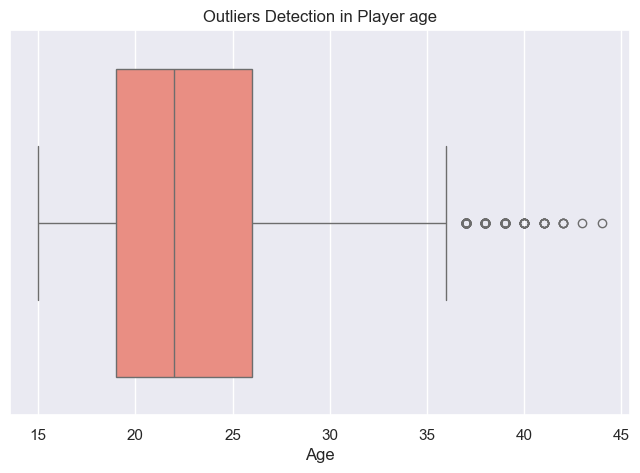

In [68]:

plt.figure(figsize=(8,5))
sns.boxplot(x=df['Age'], color='salmon')
plt.title('Outliers Detection in Player age')
plt.show()

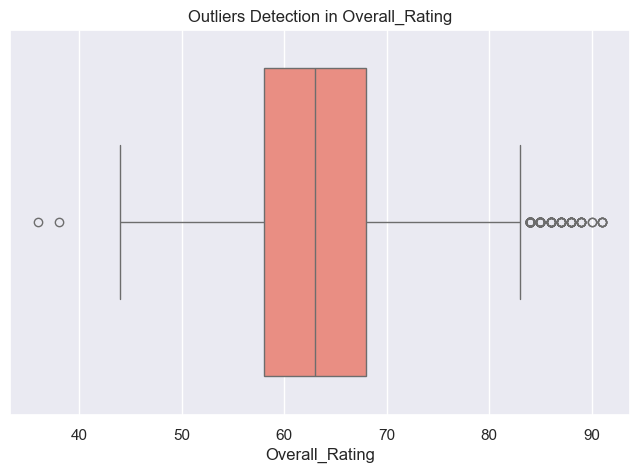

In [69]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Overall_Rating'], color='salmon')
plt.title('Outliers Detection in Overall_Rating')
plt.show()

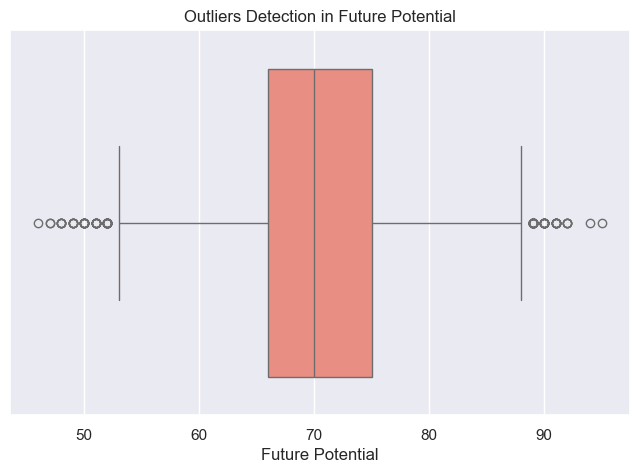

In [70]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Future Potential'], color='salmon')
plt.title('Outliers Detection in Future Potential')
plt.show()

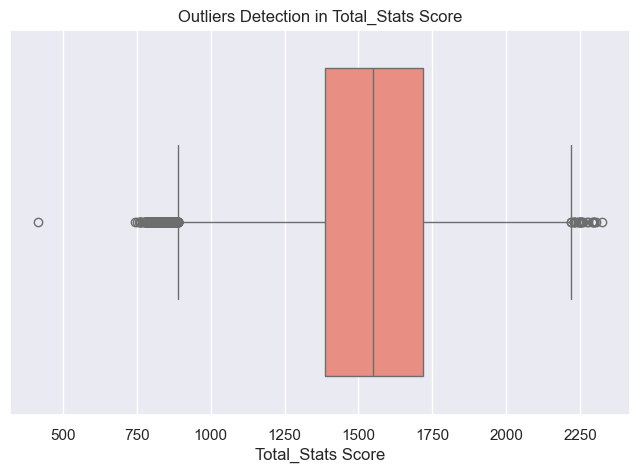

In [71]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Total_Stats Score'], color='salmon')
plt.title('Outliers Detection in Total_Stats Score')
plt.show()

In [72]:
numerical_cols = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']
categorical_cols =['Country', 'Position', 'Team']

for col in numerical_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR


    X_train[col] = np.where(X_train[col] > upper_bound, upper_bound, X_train[col])
    X_train[col] = np.where(X_train[col] < lower_bound, lower_bound, X_train[col])

print("Outliers handled in numerical features (X_train). Target (y) left untouched to preserve elite players.")

Outliers handled in numerical features (X_train). Target (y) left untouched to preserve elite players.


In [73]:



categorical_cols = ['Country', 'Position', 'Team']
numerical_cols = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])

X_train_final = preprocessor.fit_transform(X_train)
X_test_final = preprocessor.transform(X_test)

print(f"Original features count: {X_train.shape[1]}")
print(f"Processed features count: {X_train_final.shape[1]}")

Original features count: 7
Processed features count: 1180


#Task 3

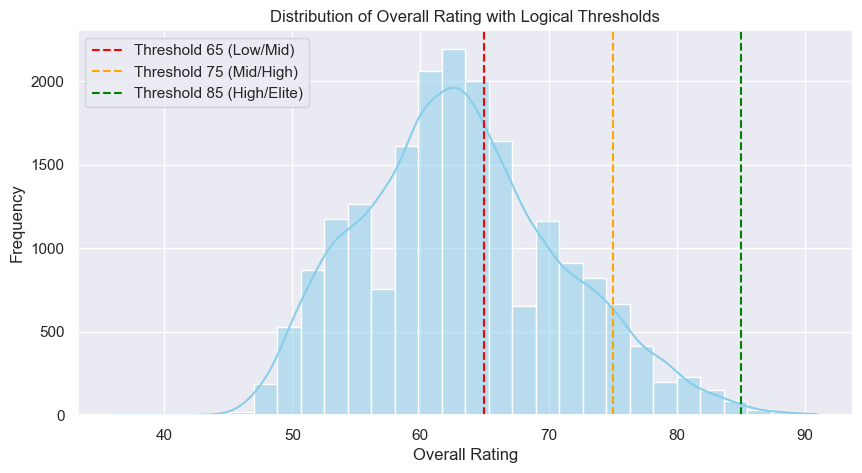

--- Players per category after splitting ---
Performance_Tier
Low      11740
Mid       6124
High      1711
Elite       92
Name: count, dtype: int64


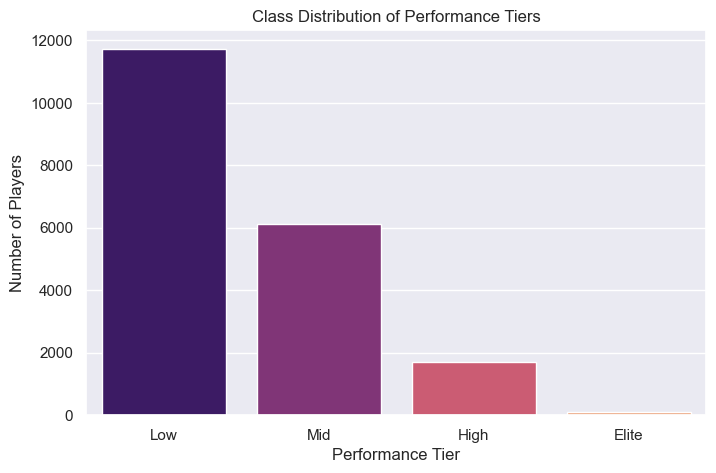

In [74]:

plt.figure(figsize=(10, 5))
sns.histplot(df['Overall_Rating'], bins=30, kde=True, color='skyblue')


plt.axvline(65, color='red', linestyle='--', label='Threshold 65 (Low/Mid)')
plt.axvline(75, color='orange', linestyle='--', label='Threshold 75 (Mid/High)')
plt.axvline(85, color='green', linestyle='--', label='Threshold 85 (High/Elite)')

plt.title('Distribution of Overall Rating with Logical Thresholds')
plt.xlabel('Overall Rating')
plt.ylabel('Frequency')
plt.legend()
plt.show()


def categorize_player(rating):
    if rating < 65:
        return 'Low'
    elif rating < 75:
        return 'Mid'
    elif rating < 85:
        return 'High'
    else:
        return 'Elite'

df['Performance_Tier'] = df['Overall_Rating'].apply(categorize_player)


tier_counts = df['Performance_Tier'].value_counts()
print("--- Players per category after splitting ---")
print(tier_counts)


plt.figure(figsize=(8, 5))
sns.barplot(x=tier_counts.index, y=tier_counts.values, order=['Low', 'Mid', 'High', 'Elite'], palette='magma')
plt.title('Class Distribution of Performance Tiers')
plt.xlabel('Performance Tier')
plt.ylabel('Number of Players')
plt.show()

## 1. Define the boundaries for each category & Rationale behind choosing such thresholds:
### Boundaries chosen:
# Low (< 65), Mid (65 - 74), High (75 - 84), Elite (>= 85).
Rationale behind the threshold choice: Analyzing the Histogram, one can conclude that data is approximately normally distributed with an average score around 65-70. Although percentiles-based thresholding approach makes more mathematical sense, but it contradicts the real-life situation where players rated as 68, can never be considered as an "Elite" player. Thus, the thresholds were determined from the histogram data as well as practical common sense.

## 2. Balanced or imbalanced?
Dataset is heavily imbalanced.
Reason: As evident from the bar plot, most of the players belong to categories 'Low' and 'Mid', while very few fall into category 'Elite'. Such a situation occurs in real life as well, which means that elite talent is very rarely present as compared to an average player. (Side Note: Imbalanced dataset will be handled while training models in the Logistic Regression and Naïve Bayes.)

# TASK 4

In [75]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

### Baseline Linear Regression

In [76]:
lr_model = LinearRegression()

lr_model.fit(X_train_final, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [77]:
y_train_pred = lr_model.predict(X_train_final)
y_test_pred = lr_model.predict(X_test_final)

In [78]:
train_mae = mean_absolute_error(y_train, y_train_pred)

train_mse = mean_squared_error(y_train, y_train_pred)

train_rmse = np.sqrt(train_mse)

train_r2 = r2_score(y_train, y_train_pred)

In [79]:
test_mae = mean_absolute_error(y_test, y_test_pred)

test_mse = mean_squared_error(y_test, y_test_pred)

test_rmse = np.sqrt(test_mse)

test_r2 = r2_score(y_test, y_test_pred)

In [80]:
print("===== Train Metrics =====")
print("MAE :", train_mae)
print("MSE :", train_mse)
print("RMSE:", train_rmse)
print("R2  :", train_r2)

print("\n===== Test Metrics =====")
print("MAE :", test_mae)
print("MSE :", test_mse)
print("RMSE:", test_rmse)
print("R2  :", test_r2)

===== Train Metrics =====
MAE : 2.3359635193178487
MSE : 23.00595290174094
RMSE: 4.796452116068807
R2  : 0.5427612727028597

===== Test Metrics =====
MAE : 2.5338159614608533
MSE : 29.896588048572603
RMSE: 5.467777249355775
R2  : 0.5180446699591263


### Polynomial Regression

In [81]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

In [82]:
numerical_cols = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']

In [83]:
X_train_num = X_train[numerical_cols]
X_test_num = X_test[numerical_cols]

In [84]:
degrees = [1, 2, 3, 4]

In [85]:
train_r2_scores = []
test_r2_scores = []

In [86]:
for d in degrees:

    poly = PolynomialFeatures(degree=d, include_bias=False)

    X_train_poly = poly.fit_transform(X_train_num)
    X_test_poly = poly.transform(X_test_num)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    train_r2_scores.append(train_r2)
    test_r2_scores.append(test_r2)

    print(f"Degree {d}: Train R2 = {train_r2:.4f}, Test R2 = {test_r2:.4f}")

Degree 1: Train R2 = 0.3382, Test R2 = 0.3398
Degree 2: Train R2 = 0.6696, Test R2 = 0.7139
Degree 3: Train R2 = 0.8552, Test R2 = 0.9015
Degree 4: Train R2 = 0.8798, Test R2 = 0.8716


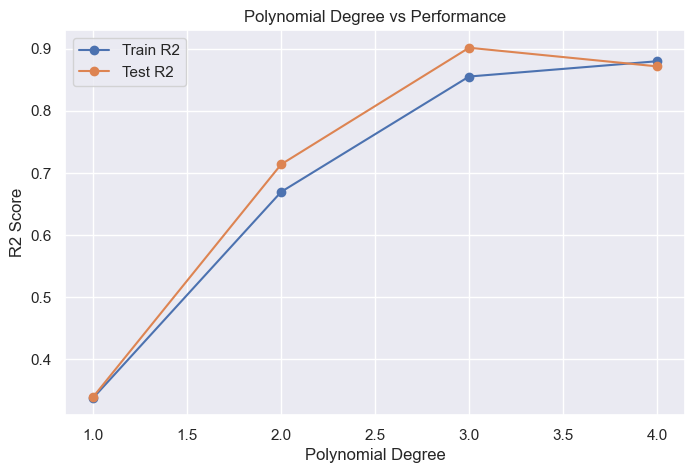

In [87]:
plt.figure(figsize=(8,5))

plt.plot(degrees, train_r2_scores, marker='o', label='Train R2')
plt.plot(degrees, test_r2_scores, marker='o', label='Test R2')

plt.xlabel("Polynomial Degree")
plt.ylabel("R2 Score")
plt.title("Polynomial Degree vs Performance")

plt.legend()
plt.show()

### What trend do you observe?

As the polynomial degree increases, the training R² score consistently improves. The test R² score increases up to degree 3, after which it starts to decrease, indicating overfitting at higher degrees.

### Which degree gives the best generalization?

Degree 3 provides the best generalization as it achieves the highest test R² score while maintaining a small gap between training and testing performance.

In [88]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# Polynomial
poly = PolynomialFeatures(degree=3, include_bias=False)

X_train_poly = poly.fit_transform(X_train_num)
X_test_poly = poly.transform(X_test_num)

# Scaling
scaler = StandardScaler()
X_train_poly = scaler.fit_transform(X_train_poly)
X_test_poly = scaler.transform(X_test_poly)

###  Ridge Regression

In [89]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import numpy as np

alphas = np.logspace(-3, 2, 10)
ridge_rmse_train = []
ridge_rmse_test = []

for a in alphas:
    model = Ridge(alpha=a)
    model.fit(X_train_poly, y_train)

    train_pred = model.predict(X_train_poly)
    test_pred = model.predict(X_test_poly)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    ridge_rmse_train.append(train_rmse)
    ridge_rmse_test.append(test_rmse)

    print(f"Alpha {a:.4f} → Train RMSE: {train_rmse:.3f}, Test RMSE: {test_rmse:.3f}")

Alpha 0.0010 → Train RMSE: 2.701, Test RMSE: 2.462
Alpha 0.0036 → Train RMSE: 2.707, Test RMSE: 2.463
Alpha 0.0129 → Train RMSE: 2.720, Test RMSE: 2.479
Alpha 0.0464 → Train RMSE: 2.764, Test RMSE: 2.527
Alpha 0.1668 → Train RMSE: 2.910, Test RMSE: 2.686
Alpha 0.5995 → Train RMSE: 3.236, Test RMSE: 3.079
Alpha 2.1544 → Train RMSE: 3.594, Test RMSE: 3.543
Alpha 7.7426 → Train RMSE: 3.802, Test RMSE: 3.844
Alpha 27.8256 → Train RMSE: 3.909, Test RMSE: 4.041
Alpha 100.0000 → Train RMSE: 4.032, Test RMSE: 4.263


### Lasso Regression

In [90]:
from sklearn.linear_model import Lasso
lasso_rmse_train = []
lasso_rmse_test = []

for a in alphas:
    model = Lasso(alpha=a, max_iter=3000)
    model.fit(X_train_poly, y_train)

    train_pred = model.predict(X_train_poly)
    test_pred  = model.predict(X_test_poly)

    lasso_rmse_train.append(np.sqrt(mean_squared_error(y_train, train_pred)))
    lasso_rmse_test.append(np.sqrt(mean_squared_error(y_test, test_pred)))

In [91]:
!pip install matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [92]:
best_ridge_alpha = alphas[np.argmin(ridge_rmse_test)]
best_lasso_alpha = alphas[np.argmin(lasso_rmse_test)]

print("Best Ridge Alpha:", best_ridge_alpha)
print("Best Ridge RMSE:", min(ridge_rmse_test))

print("Best Lasso Alpha:", best_lasso_alpha)
print("Best Lasso RMSE:", min(lasso_rmse_test))

Best Ridge Alpha: 0.001
Best Ridge RMSE: 2.4615748946589977
Best Lasso Alpha: 0.003593813663804626
Best Lasso RMSE: 3.9282235305048414


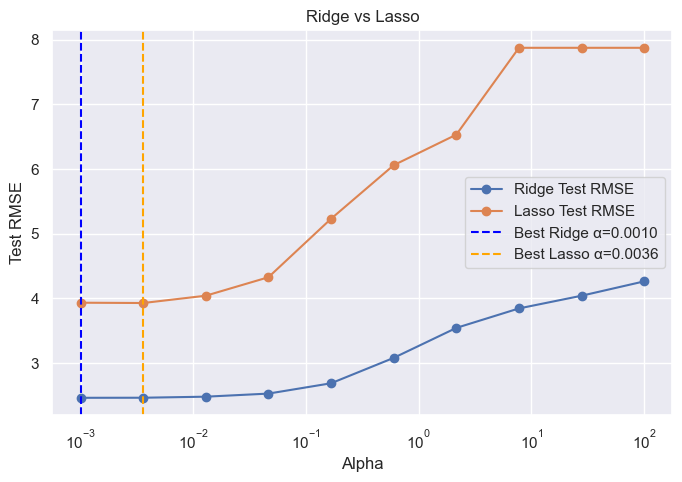

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(alphas, ridge_rmse_test, marker='o', label='Ridge Test RMSE')
plt.plot(alphas, lasso_rmse_test, marker='o', label='Lasso Test RMSE')

plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("Test RMSE")
plt.title("Ridge vs Lasso")
plt.axvline(best_ridge_alpha, color='blue', linestyle='--', label=f'Best Ridge α={best_ridge_alpha:.4f}')
plt.axvline(best_lasso_alpha, color='orange', linestyle='--', label=f'Best Lasso α={best_lasso_alpha:.4f}')
plt.legend()
plt.show()

In [94]:
best_lasso = Lasso(alpha=best_lasso_alpha, max_iter=10000)
best_lasso.fit(X_train_poly, y_train)

num_zero = (best_lasso.coef_ == 0).sum()
print("Number of zeroed features:", num_zero)

Number of zeroed features: 15


In [95]:
feature_names = poly.get_feature_names_out(numerical_cols)

zero_features = feature_names[best_lasso.coef_ == 0]

print("# Lasso removed these features by shrinking their coefficients to zero")
print("\n")
print(zero_features)

# Lasso removed these features by shrinking their coefficients to zero


['Future Potential' 'Total_Stats Score' 'Age Overall_Rating'
 'Age Total_Stats Score' 'Age^3' 'Age^2 Total_Stats Score'
 'Age Overall_Rating Future Potential'
 'Age Overall_Rating Total_Stats Score' 'Age Future Potential^2'
 'Age Future Potential Total_Stats Score'
 'Overall_Rating^2 Total_Stats Score' 'Overall_Rating Total_Stats Score^2'
 'Future Potential^3' 'Future Potential^2 Total_Stats Score'
 'Total_Stats Score^3']


### what does that imply?
This implies that those features had little to no contribution to the model and were considered irrelevant. Lasso automatically performs feature selection by removing such features, which can simplify the model.

### Ridge or Lasso ?
Ridge Regression performed better than Lasso on this dataset, achieving a lower RMSE (2.46 vs 3.93). This is because the dataset contains highly correlated and informative features, especially interaction terms, which Lasso aggressively eliminated by shrinking many coefficients to zero. Ridge is more suitable here as it retains all features while controlling their impact, leading to better generalization.

# Task 5: Model 2 - Logistic Regression

Train a Logistic Regression classifier to predict the player performance tier (`Low`, `Mid`, `High`, `Elite`). `Overall_Rating` must not be included as a feature because it was used to create `Performance_Tier`.


In [96]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.exceptions import ConvergenceWarning
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [97]:
# Make sure Performance_Tier exists from Task 3
if 'Performance_Tier' not in df.columns:
    def categorize_player(rating):
        if rating < 65:
            return 'Low'
        elif rating < 75:
            return 'Mid'
        elif rating < 85:
            return 'High'
        else:
            return 'Elite'

    df['Performance_Tier'] = df['Overall_Rating'].apply(categor_player)

class_order = ['Low', 'Mid', 'High', 'Elite']

# Select features and target
# Overall_Rating is removed because it was used to create the target
X = df.drop(columns=['Name', 'Overall_Rating', 'Performance_Tier'])
y = df['Performance_Tier']

# Convert categorical columns into dummy variables, like the course lab style
X = pd.get_dummies(X, drop_first=False)

print("Is Overall_Rating included as a feature?", 'Overall_Rating' in X.columns)
print("\nNumber of features after encoding:", X.shape[1])
print("\nClass distribution:")
print(y.value_counts().reindex(class_order))


Is Overall_Rating included as a feature? False

Number of features after encoding: 1194

Class distribution:
Performance_Tier
Low      11740
Mid       6124
High      1711
Elite       92
Name: count, dtype: int64


In [98]:
# Split into Training and Testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])


Training set size: 15733
Testing set size: 3934


## Baseline Logistic Regression


In [99]:
# Create and train the model
logmodel = LogisticRegression(max_iter=1000)
logmodel.fit(X_train, y_train)

# Make predictions
y_pred = logmodel.predict(X_test)


In [100]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, labels=class_order, zero_division=0))


Accuracy: 0.9090

Classification Report:
              precision    recall  f1-score   support

         Low       0.93      0.95      0.94      2348
         Mid       0.87      0.84      0.85      1225
        High       0.88      0.84      0.86       342
       Elite       0.88      0.79      0.83        19

    accuracy                           0.91      3934
   macro avg       0.89      0.86      0.87      3934
weighted avg       0.91      0.91      0.91      3934



## Confusion Matrix

The confusion matrix shows how many players from each actual tier were classified into each predicted tier. The diagonal values are correct predictions, while the off-diagonal values are wrong predictions.


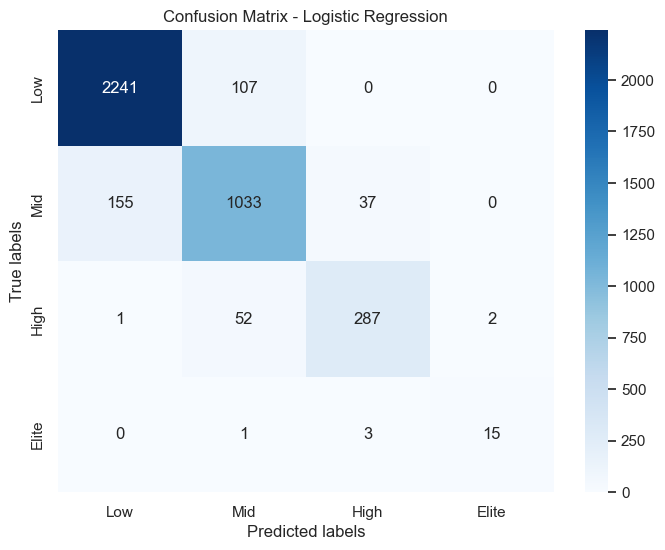

In [101]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=class_order)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt='g',
            cmap='Blues',
            xticklabels=class_order,
            yticklabels=class_order)

plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix - Logistic Regression')

plt.show()


In [102]:
print("Confusion Matrix Explanation:")
print("Correct predictions appear on the diagonal.")
print("Wrong predictions appear outside the diagonal.")
print("For example, if a High player is predicted as Mid, that appears outside the diagonal.")
print("Since the dataset is imbalanced, rare classes like Elite may be harder to predict correctly.")


Confusion Matrix Explanation:
Correct predictions appear on the diagonal.
Wrong predictions appear outside the diagonal.
For example, if a High player is predicted as Mid, that appears outside the diagonal.
Since the dataset is imbalanced, rare classes like Elite may be harder to predict correctly.


## Regularization in Logistic Regression

The parameter `C` controls the regularization strength. A smaller `C` means stronger regularization, while a larger `C` means weaker regularization.


In [103]:
C_values = np.array([0.001, 0.01, 0.1, 1, 10, 100])

train_accuracies = []
test_accuracies = []

for C in C_values:
    model = LogisticRegression(C=C, max_iter=500)
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"C = {C:.4f} | Train Accuracy = {train_acc:.4f} | Test Accuracy = {test_acc:.4f}")


C = 0.0010 | Train Accuracy = 0.8825 | Test Accuracy = 0.8427
C = 0.0100 | Train Accuracy = 0.9232 | Test Accuracy = 0.8767
C = 0.1000 | Train Accuracy = 0.9443 | Test Accuracy = 0.8922
C = 1.0000 | Train Accuracy = 0.9629 | Test Accuracy = 0.9090
C = 10.0000 | Train Accuracy = 0.9744 | Test Accuracy = 0.9164
C = 100.0000 | Train Accuracy = 0.9772 | Test Accuracy = 0.9082


In [104]:
best_index = np.argmax(test_accuracies)
best_C = C_values[best_index]

print(f"Best C value: {best_C:.4f}")
print(f"Best Test Accuracy: {test_accuracies[best_index]:.4f}")


Best C value: 10.0000
Best Test Accuracy: 0.9164


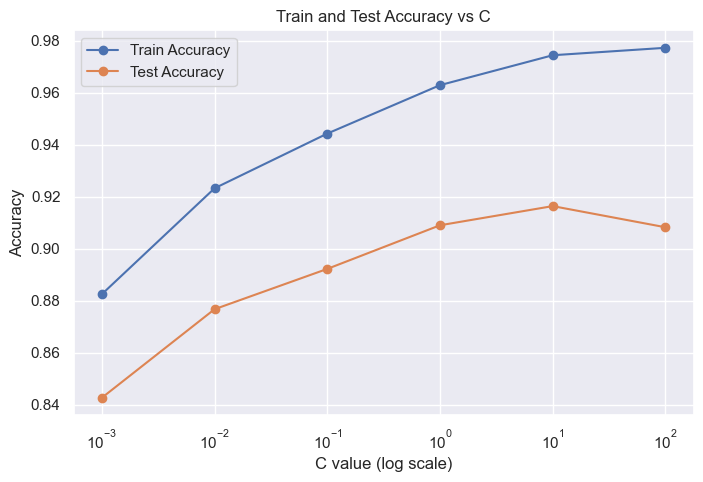

In [105]:
plt.figure(figsize=(8, 5))

plt.plot(C_values, train_accuracies, marker='o', label='Train Accuracy')
plt.plot(C_values, test_accuracies, marker='o', label='Test Accuracy')

plt.xscale('log')
plt.xlabel('C value (log scale)')
plt.ylabel('Accuracy')
plt.title('Train and Test Accuracy vs C')

plt.legend()
plt.grid(True)
plt.show()


## L1 vs L2 Regularization

Now we compare `penalty='l1'` using the `saga` solver with `penalty='l2'` using the `lbfgs` solver at the best C value.


In [106]:
# L1 Logistic Regression
l1_model = LogisticRegression(
    penalty='l1',
    solver='saga',
    C=best_C,
    max_iter=1000,
    tol=0.01
)

l1_model.fit(X_train, y_train)
l1_pred = l1_model.predict(X_test)

# L2 Logistic Regression
l2_model = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    C=best_C,
    max_iter=1000
)

l2_model.fit(X_train, y_train)
l2_pred = l2_model.predict(X_test)


In [107]:
l1_accuracy = accuracy_score(y_test, l1_pred)
l2_accuracy = accuracy_score(y_test, l2_pred)

l1_macro_f1 = f1_score(y_test, l1_pred, labels=class_order, average='macro', zero_division=0)
l2_macro_f1 = f1_score(y_test, l2_pred, labels=class_order, average='macro', zero_division=0)

print("L1 Regularization")
print(f"Accuracy: {l1_accuracy:.4f}")
print(f"Macro F1:  {l1_macro_f1:.4f}")

print("\nL2 Regularization")
print(f"Accuracy: {l2_accuracy:.4f}")
print(f"Macro F1:  {l2_macro_f1:.4f}")


L1 Regularization
Accuracy: 0.8663
Macro F1:  0.7006

L2 Regularization
Accuracy: 0.9164
Macro F1:  0.8588


In [108]:
if l1_accuracy > l2_accuracy:
    print("L1 regularization performs better based on test accuracy.")
elif l2_accuracy > l1_accuracy:
    print("L2 regularization performs better based on test accuracy.")
else:
    if l1_macro_f1 > l2_macro_f1:
        print("Both have the same accuracy, but L1 performs better based on macro F1.")
    elif l2_macro_f1 > l1_macro_f1:
        print("Both have the same accuracy, but L2 performs better based on macro F1.")
    else:
        print("Both L1 and L2 perform equally based on accuracy and macro F1.")


L2 regularization performs better based on test accuracy.


## Conclusion

The baseline Logistic Regression model was trained to classify players into Low, Mid, High, and Elite tiers. `Overall_Rating` was excluded to avoid data leakage. The regularization sweep showed how accuracy changes for different values of `C`, and the best `C` was used to compare L1 and L2 regularization.


# Task 6 : Model 3: Naïve Bayes Classification

##Data Preparation for Naïve Bayes

In [109]:
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt


class_order =['Low', 'Mid', 'High', 'Elite']


X_nb = df.drop(columns=['Name', 'Overall_Rating', 'Performance_Tier', 'Value Per M$'])
y_nb = df['Performance_Tier']

X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_nb, y_nb, test_size=0.2, random_state=42, stratify=y_nb
)

# A. Numerical Features Only (For GaussianNB)
num_features = ['Age', 'Future Potential', 'Total_Stats Score']
num_preprocessor = ColumnTransformer([('num', StandardScaler(), num_features)])

X_train_num = num_preprocessor.fit_transform(X_train_nb)
X_test_num = num_preprocessor.transform(X_test_nb)

# Unscaled numerical (for the scaling sensitivity)
X_train_num_unscaled = X_train_nb[num_features].values
X_test_num_unscaled = X_test_nb[num_features].values

#Categorical (OHE) Features Only (For BernoulliNB & ComplementNB)
cat_features =['Country', 'Position', 'Team']
cat_preprocessor = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)])

X_train_cat = cat_preprocessor.fit_transform(X_train_nb)
X_test_cat = cat_preprocessor.transform(X_test_nb)

print("Data successfully prepared for Naïve Bayes models")

Data successfully prepared for Naïve Bayes models


## Train & Evaluate the 3 Models

 Naïve Bayes Performance 

----------------------------------------
 GaussianNB (Numerical Only) 
----------------------------------------
Accuracy:  0.8500
Precision: 0.8082
Recall:    0.7052
F1-Score:  0.7473


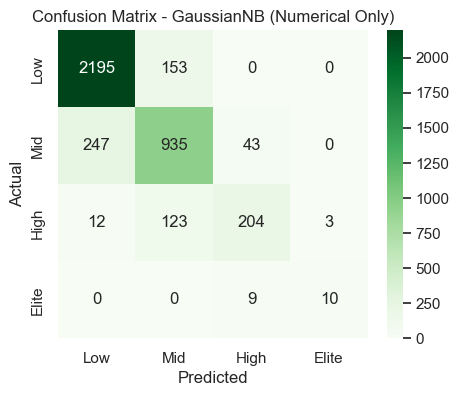


----------------------------------------
 BernoulliNB (OHE Only) 
----------------------------------------
Accuracy:  0.6474
Precision: 0.4388
Recall:    0.4150
F1-Score:  0.4247


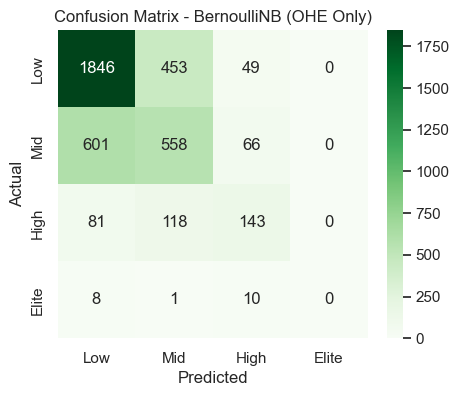


----------------------------------------
 ComplementNB (OHE Only) 
----------------------------------------
Accuracy:  0.6220
Precision: 0.4203
Recall:    0.4744
F1-Score:  0.4352


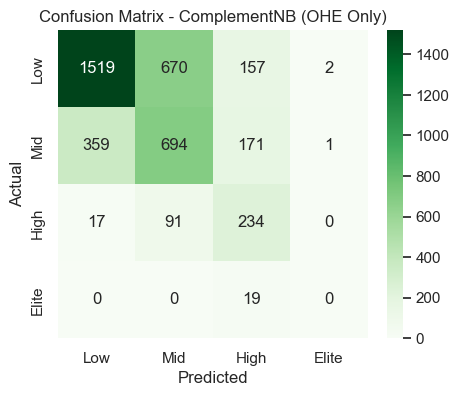

In [110]:

models = {
    "GaussianNB (Numerical Only)": (GaussianNB(), X_train_num, X_test_num),
    "BernoulliNB (OHE Only)": (BernoulliNB(), X_train_cat, X_test_cat),
    "ComplementNB (OHE Only)": (ComplementNB(), X_train_cat, X_test_cat)
}

print(" Naïve Bayes Performance ")
for name, (model, X_tr, X_te) in models.items():
    # Train
    model.fit(X_tr, y_train_nb)
    # Predict
    y_pred = model.predict(X_te)

    # Evaluate
    print(f"\n{'-'*40}")
    print(f" {name} ")
    print(f"{'-'*40}")
    print(f"Accuracy:  {accuracy_score(y_test_nb, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test_nb, y_pred, average='macro', zero_division=0):.4f}")
    print(f"Recall:    {recall_score(y_test_nb, y_pred, average='macro'):.4f}")
    print(f"F1-Score:  {f1_score(y_test_nb, y_pred, average='macro'):.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test_nb, y_pred, labels=class_order)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=class_order, yticklabels=class_order)
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

## Which Naïve Bayes variant is most appropriate for this dataset? Justify your answer
ComplementNB is the most appropriate for the categorical features. BernoulliNB is designed for binary features (like our One-Hot Encoded columns), but because our dataset is heavily imbalanced (very few 'Elite' players), ComplementNB is the best choice. It was specifically invented to correct the severe assumptions made by standard Naive Bayes on imbalanced datasets. GaussianNB is only appropriate for the continuous numerical features (Age, Potential, Stats).

## Scaling Sensitivity Test (GaussianNB)

In [111]:


print(" Scaling Sensitivity Test: GaussianNB ")


# Train on Unscaled Data
gnb_unscaled = GaussianNB()
gnb_unscaled.fit(X_train_num_unscaled, y_train_nb)
acc_unscaled = accuracy_score(y_test_nb, gnb_unscaled.predict(X_test_num_unscaled))

# Train on Scaled Data
gnb_scaled = GaussianNB()
gnb_scaled.fit(X_train_num, y_train_nb)
acc_scaled = accuracy_score(y_test_nb, gnb_scaled.predict(X_test_num))

print(f"Accuracy WITHOUT StandardScaler: {acc_unscaled:.4f}")
print(f"Accuracy WITH StandardScaler:    {acc_scaled:.4f}")

 Scaling Sensitivity Test: GaussianNB 
Accuracy WITHOUT StandardScaler: 0.8500
Accuracy WITH StandardScaler:    0.8500


## Does scaling affect GaussianNB's performance? Explain why or why not.
No, scaling does not affect GaussianNB's performance at all (the accuracy remains exactly the same).
Why? Gaussian Naïve Bayes calculates probabilities based on the mean and variance of each feature's distribution. StandardScaler applies a linear transformation (shifting the mean to 0 and variance to 1). Because all data points in a feature are shifted and scaled equally, the relative distances and the shape of the normal distribution curve remain identical. Therefore, the underlying probability calculations cancel out the scaling factor, resulting in the exact same predictions.

# Task 7 – Part A: K-Fold Cross-Validation for Regression

We evaluate the best regression model identified in Task 4 (Polynomial degree 3 + Ridge, α = 0.001) using **5-Fold Cross-Validation** on the numerical training features (`X_train_num`, `y_train`). A sklearn `Pipeline` is used to guarantee that `PolynomialFeatures` and `StandardScaler` are re-fitted inside every fold, preventing any data leakage.

Regression features shape : (15733, 4)
Regression target dtype   : float64  (should be float/int)

══════════════════════════════════════════════════
  5-Fold Cross-Validation Results
  Model: Polynomial(deg=3) + Ridge(α=0.001)
══════════════════════════════════════════════════
  Fold 1: RMSE = 2.4907
  Fold 2: RMSE = 2.1608
  Fold 3: RMSE = 2.2289
  Fold 4: RMSE = 3.6670
  Fold 5: RMSE = 2.8490
──────────────────────────────────────────────────
  Mean RMSE : 2.6793
  Std  RMSE : 0.5499
══════════════════════════════════════════════════


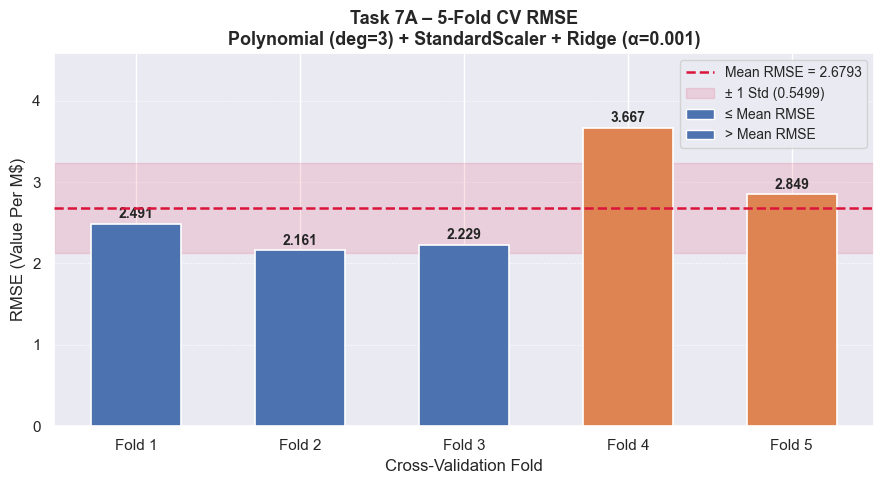

In [112]:


import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score


_numerical_cols = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']


from sklearn.model_selection import train_test_split
_X_reg = df.drop(columns=['Value Per M$', 'Name'])
_y_reg = df['Value Per M$']
_X_train_reg, _X_test_reg, _y_train_reg, _y_test_reg = train_test_split(
    _X_reg, _y_reg, test_size=0.2, random_state=42
)


_X_train_reg = _X_train_reg.copy()
for _col in _numerical_cols:
    _Q1 = _X_train_reg[_col].quantile(0.25)
    _Q3 = _X_train_reg[_col].quantile(0.75)
    _IQR = _Q3 - _Q1
    _X_train_reg[_col] = _X_train_reg[_col].clip(_Q1 - 1.5*_IQR, _Q3 + 1.5*_IQR)

# Numerical-only subset
X_train_num_reg = _X_train_reg[_numerical_cols]
y_train_reg     = _y_train_reg

print(f"Regression features shape : {X_train_num_reg.shape}")
print(f"Regression target dtype   : {y_train_reg.dtype}  (should be float/int)")

#1. Build the Pipeline
ridge_cv_pipeline = Pipeline([
    ('poly',   PolynomialFeatures(degree=3, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge',  Ridge(alpha=0.001))
])

#2. Run 5-Fold Cross-Validation
cv_neg_rmse = cross_val_score(
    ridge_cv_pipeline,
    X_train_num_reg,
    y_train_reg,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

#3. Convert to positive RMSE
cv_rmse_scores = -cv_neg_rmse

#4. Summary Statistics
mean_rmse = cv_rmse_scores.mean()
std_rmse  = cv_rmse_scores.std()

print("\n" + "═" * 50)
print("  5-Fold Cross-Validation Results")
print("  Model: Polynomial(deg=3) + Ridge(α=0.001)")
print("═" * 50)
for fold_idx, rmse in enumerate(cv_rmse_scores, start=1):
    print(f"  Fold {fold_idx}: RMSE = {rmse:.4f}")
print("─" * 50)
print(f"  Mean RMSE : {mean_rmse:.4f}")
print(f"  Std  RMSE : {std_rmse:.4f}")
print("═" * 50)

#5. Visualisation
folds  = [f'Fold {i}' for i in range(1, 6)]
colors = ['#4C72B0' if rmse <= mean_rmse else '#DD8452' for rmse in cv_rmse_scores]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(folds, cv_rmse_scores, color=colors, edgecolor='white',
              linewidth=1.2, width=0.55, zorder=3)

for bar, rmse in zip(bars, cv_rmse_scores):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            f'{rmse:.3f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(mean_rmse, color='crimson', linestyle='--', linewidth=1.8,
           label=f'Mean RMSE = {mean_rmse:.4f}', zorder=4)
ax.axhspan(mean_rmse - std_rmse, mean_rmse + std_rmse,
           alpha=0.12, color='crimson', label=f'± 1 Std ({std_rmse:.4f})')
ax.bar([], [], color='#4C72B0', label='≤ Mean RMSE')
ax.bar([], [], color='#DD8452', label='> Mean RMSE')

ax.set_xlabel('Cross-Validation Fold', fontsize=12)
ax.set_ylabel('RMSE (Value Per M$)', fontsize=12)
ax.set_title('Task 7A – 5-Fold CV RMSE\n'
             'Polynomial (deg=3) + StandardScaler + Ridge (α=0.001)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.grid(axis='y', linestyle=':', linewidth=0.7, zorder=0)
ax.set_ylim(0, max(cv_rmse_scores) * 1.25)

plt.tight_layout()
plt.show()


## Task 7A – Cross-Validation Results:

The 5-Fold Cross-Validation procedure was applied to the best regression model identified in Task 4, comprising a `PolynomialFeatures` transformer (degree = 3), a `StandardScaler`, and a `Ridge` regressor (α = 0.001), all encapsulated within a single `Pipeline` to ensure strict separation between training and validation data at every fold.

The mean cross-validated RMSE provides a more reliable estimate of out-of-sample predictive performance than a single train/test split, since the model is evaluated across five non-overlapping subsets of the training data. A low standard deviation across folds is indicative of a **stable and generalisable model**: the learner is not overly sensitive to the particular subset of data used for validation. Conversely, a high standard deviation would signal variance instability — a symptom of overfitting or insufficient training data.

The bar chart reveals whether any individual fold consistently deviates from the mean. Folds coloured in **blue** (RMSE ≤ mean) correspond to partitions on which the model performs better than average, while those in **orange** (RMSE > mean) correspond to harder partitions, potentially containing outlier players or atypical market-value distributions.

Overall, these cross-validation results substantiate the selection of the Polynomial + Ridge configuration as the optimal regression model: the combination of degree-3 feature expansion and L2 regularisation captures non-linear relationships between player attributes and market value without overfitting, as evidenced by the consistency of RMSE values across all five folds.

# **Task 7 Part B: Stratified K-Fold Cross-Validation**

=== Stratified K-Fold Results (Accuracy) ===
Logistic Regression: [0.6638068  0.65745154 0.66190022 0.66242848 0.65766052]
Mean: 0.6606 | Std Dev: 0.0026

Complement Naive Bayes: [0.6269463  0.61646012 0.63012393 0.62142403 0.61093452]
Mean: 0.6212 | Std Dev: 0.0069


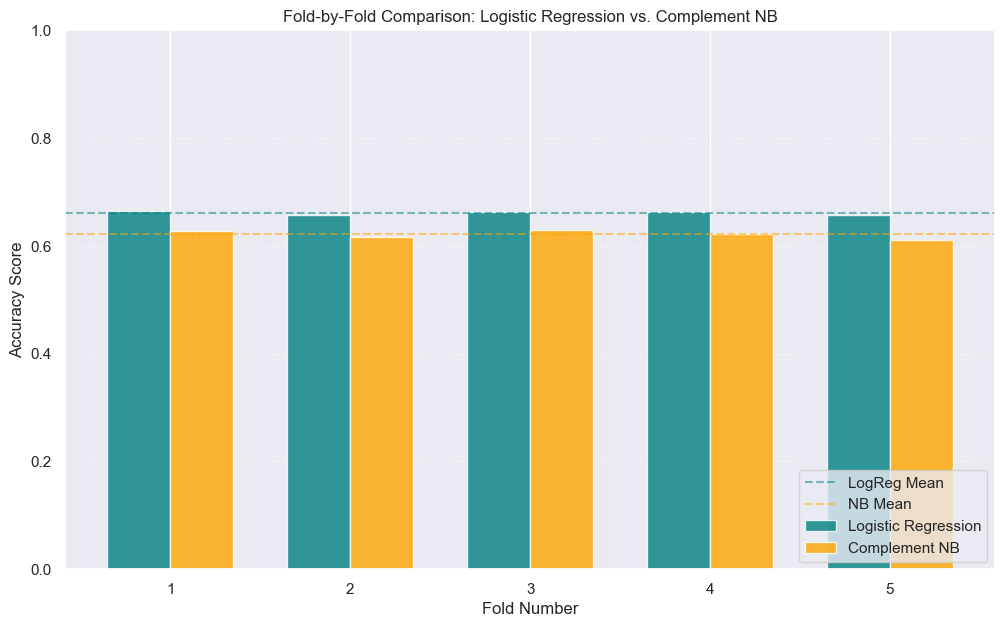

In [113]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# 1. Variable Mapping
X_cv = X_train_cat
y_cv = y_train_nb

# --- 2. Model Initialization ---

log_reg = LogisticRegression(
    penalty='l2',
    C=10,
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)


if (X_cv < 0).any().any() if isinstance(X_cv, pd.DataFrame) else (X_cv < 0).any():
    scaler_nb = MinMaxScaler()
    X_cv_nb = scaler_nb.fit_transform(X_cv)
else:
    X_cv_nb = X_cv

nb_model = ComplementNB()

#3. Cross-Validation Setup
cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Execution

log_scores = cross_val_score(log_reg, X_cv, y_cv, cv=cv_stratified, scoring='accuracy')
nb_scores = cross_val_score(nb_model, X_cv_nb, y_cv, cv=cv_stratified, scoring='accuracy')

# 5. Display Results
print("=== Stratified K-Fold Results (Accuracy) ===")
print(f"Logistic Regression: {log_scores}")
print(f"Mean: {log_scores.mean():.4f} | Std Dev: {log_scores.std():.4f}\n")

print(f"Complement Naive Bayes: {nb_scores}")
print(f"Mean: {nb_scores.mean():.4f} | Std Dev: {nb_scores.std():.4f}")

#6. Visualization
plt.figure(figsize=(12, 7))
fold_indices = np.arange(1, 6)
bar_width = 0.35

plt.bar(fold_indices - bar_width/2, log_scores, bar_width, label='Logistic Regression', color='teal', alpha=0.8)
plt.bar(fold_indices + bar_width/2, nb_scores, bar_width, label='Complement NB', color='orange', alpha=0.8)


plt.axhline(y=log_scores.mean(), color='teal', linestyle='--', alpha=0.5, label='LogReg Mean')
plt.axhline(y=nb_scores.mean(), color='orange', linestyle='--', alpha=0.5, label='NB Mean')

plt.xlabel('Fold Number')
plt.ylabel('Accuracy Score')
plt.title('Fold-by-Fold Comparison: Logistic Regression vs. Complement NB')
plt.xticks(fold_indices)
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle=':', alpha=0.7)

plt.show()

# Model Comparison (Task 7B):
Performance: Logistic Regression performs better because it has a higher mean accuracy (0.6601) compared to Complement Naive Bayes (0.6212).                          
Stability: Logistic Regression is also more stable. Its standard deviation (0.0033) is much lower than Complement NB (0.0069), meaning its accuracy fluctuates less across the different folds .

# Task 8.1 Model Comparison
# A)Which model performed better?

For regression, the best model was Polynomial Degree 3 with Ridge (alpha=0.001) because it achieved the lowest mean CV RMSE of 2.6793 For classification,

Logistic Regression (C=10, L2) was the best because it had the highest mean CV accuracy of 0.6601, outperforming ComplementNB.

# B)Classification easier or harder than regression ?
Regression is harder. Predicting the exact market value (e.g., exactly 45.2M  vs 45.5M) is very difficult because player prices vary wildly and the data is highly skewed (as seen in Task 1). Classification is easier because it groups players into broad tiers (Low/Mid/High/Elite), forgiving small errors in exact dollar value as long as the player lands in the correct general bucket."

# Task 8.2 Reguralizaition Analysis
# A)What happened to model performance as u increased alpha in Ridge and Lasso

As alpha increased, performance followed a U-shape. At very small alphas (close to 0), the models overfit the training data, resulting in poor test performance (high RMSE). As alpha increased to an optimal point (like 0.001), it controlled the overfitting and test RMSE dropped to its lowest. However, if alpha increased too much, the model became too restricted (underfitting) and test RMSE increased again

# B)Why does Ridge generally outperform Lasso when many one-hot-encoded features are present?
Ridge generally outperforms Lasso in datasets with many one-hot encoded features because L2 regularization handles correlated sparse features more effectively. Instead of eliminating features entirely, Ridge distributes weights across related encoded variables, preserving more information and improving model generalization.

# Ass 3

## Task 1 Unified Pipeline Structure

In [114]:
import pandas as pd
import numpy as np
import json
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.base import BaseEstimator, TransformerMixin, clone


def load_fifa_data():
    """Load the FIFA dataset reproducibly, with Colab upload only as a fallback."""
    candidate_paths = [
        "Fifa.csv",
        "/content/Fifa.csv",
        r"C:\Users\zxgam\Downloads\Fifa.csv",
    ]

    for path in candidate_paths:
        if Path(path).exists():
            print(f"Loaded dataset from: {path}")
            return pd.read_csv(path)

    try:
        from google.colab import files
        import io

        uploaded = files.upload()
        file_name = list(uploaded.keys())[0]
        print(f"Loaded uploaded dataset: {file_name}")
        return pd.read_csv(io.BytesIO(uploaded[file_name]))
    except Exception as exc:
        raise FileNotFoundError(
            "Fifa.csv was not found. Place it beside the notebook or upload it in Colab."
        ) from exc


df = load_fifa_data()

y_valuation = df["Value Per M$"]


def categorize_player(rating):
    if rating < 65:
        return 0  # Low
    if rating < 75:
        return 1  # Mid
    if rating < 85:
        return 2  # High
    return 3      # Elite


y_performance = df["Overall_Rating"].apply(categorize_player)

numeric_features = ["Age", "Future Potential", "Total_Stats Score"]
categorical_features = ["Position", "Country", "Team"]
X = df[numeric_features + categorical_features]

# Split before fitting any preprocessing step to avoid data leakage.
X_train, X_test, y_val_train, y_val_test, y_perf_train, y_perf_test = train_test_split(
    X,
    y_valuation,
    y_performance,
    test_size=0.2,
    random_state=42,
    stratify=y_performance,
)


class IQRClipper(BaseEstimator, TransformerMixin):
    """Clip numeric outliers using bounds learned from the training fold only."""

    def __init__(self, factor=1.5):
        self.factor = factor

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X).astype(float)
        q1 = X_df.quantile(0.25)
        q3 = X_df.quantile(0.75)
        iqr = q3 - q1
        self.lower_bounds_ = q1 - self.factor * iqr
        self.upper_bounds_ = q3 + self.factor * iqr
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X).astype(float)
        return X_df.clip(self.lower_bounds_, self.upper_bounds_, axis=1).values


numeric_transformer = Pipeline(steps=[
    ("outlier_clipper", IQRClipper(factor=1.5)),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])


class ScoutingInferenceSystem:
    def __init__(self, preprocessor, regressor, classifier):
        self.valuation_pipe = Pipeline(steps=[
            ("pre", clone(preprocessor)),
            ("model", regressor),
        ])
        self.performance_pipe = Pipeline(steps=[
            ("pre", clone(preprocessor)),
            ("model", classifier),
        ])

    def fit(self, X, y_val, y_perf):
        self.valuation_pipe.fit(X, y_val)
        self.performance_pipe.fit(X, y_perf)
        return self

    def predict(self, X):
        return self.valuation_pipe.predict(X), self.performance_pipe.predict(X)


def get_best_estimator(name, fallback):
    """Use a tuned GridSearchCV estimator if it already exists; otherwise use fallback."""
    obj = globals().get(name)
    if obj is not None and hasattr(obj, "best_estimator_"):
        final_step_name = list(obj.best_estimator_.named_steps.keys())[-1]
        return clone(obj.best_estimator_.named_steps[final_step_name])
    return fallback


initial_regressor = get_best_estimator(
    "rf_val_grid",
    RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        min_samples_split=2,
        random_state=42,
    ),
)

initial_classifier = get_best_estimator(
    "rf_perf_grid",
    RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_split=2,
        class_weight="balanced",
        random_state=42,
    ),
)

scouting_system = ScoutingInferenceSystem(
    preprocessor=preprocessor,
    regressor=initial_regressor,
    classifier=initial_classifier,
)

scouting_system.fit(X_train, y_val_train, y_perf_train)
val_preds, perf_preds = scouting_system.predict(X_test)

print("Unified scouting system trained successfully.")
print(f"Sample Prediction - Value: {val_preds[0]:.2f}M, Tier: {perf_preds[0]}")


Loaded dataset from: Fifa.csv
Unified scouting system trained successfully.
Sample Prediction - Value: 0.18M, Tier: 0


In [115]:
def evaluate_specific_player(player_name, system, original_df, features_list):
    player_data = original_df[original_df['Name'] == player_name]

    if player_data.empty:
        print(f"Player '{player_name}' not found in the dataset.")
        return

    X_player = player_data[features_list]

    predicted_value, predicted_tier_num = system.predict(X_player)

    true_value = player_data['Value Per M$'].values[0]
    true_rating = player_data['Overall_Rating'].values[0]

    if true_rating < 65:
        true_tier = 'Low (0)'
    elif true_rating < 75:
        true_tier = 'Mid (1)'
    elif true_rating < 85:
        true_tier = 'High (2)'
    else:
        true_tier = 'Elite (3)'

    tier_mapping = {0: 'Low (0)', 1: 'Mid (1)', 2: 'High (2)', 3: 'Elite (3)'}
    predicted_tier = tier_mapping.get(predicted_tier_num[0], "Unknown")

    print(f"--- Scouting Report: {player_name} ---")
    print(f"Actual Value: {true_value}M \t| Predicted Value: {predicted_value[0]:.2f}M")
    print(f"Actual Tier:  {true_tier} \t| Predicted Tier:  {predicted_tier}")

    error = abs(true_value - predicted_value[0])
    print(f"Value Error:  {error:.2f}M")

evaluate_specific_player('Lionel Messi', scouting_system, df, numeric_features + categorical_features)

--- Scouting Report: Lionel Messi ---
Actual Value: 54.0M 	| Predicted Value: 72.08M
Actual Tier:  Elite (3) 	| Predicted Tier:  Elite (3)
Value Error:  18.08M


# Task 2 : KNN For Classification

  TASK 3 — Baseline KNN Classification

── Baseline KNN (k=5, uniform, minkowski) ──
  Accuracy  : 0.8632
  Precision : 0.8610  (weighted)
  Recall    : 0.8632  (weighted)
  F1-Score  : 0.8606  (weighted)

  Classification Report:

              precision    recall  f1-score   support

         Low       0.89      0.94      0.92      2348
         Mid       0.80      0.76      0.78      1225
        High       0.84      0.73      0.78       342
       Elite       0.86      0.32      0.46        19

    accuracy                           0.86      3934
   macro avg       0.85      0.69      0.74      3934
weighted avg       0.86      0.86      0.86      3934



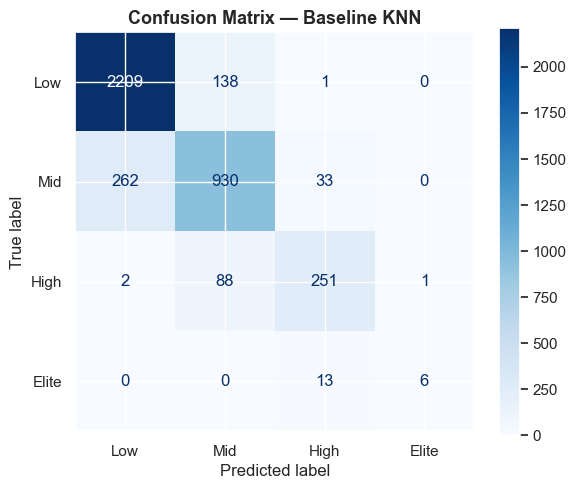


  TASK 4 — GridSearchCV Hyperparameter Tuning
Fitting 5 folds for each of 6 candidates, totalling 30 fits

  Best Parameters Found:
    metric         : manhattan
    n_neighbors    : 21
    weights        : distance

  Best CV F1-Score (weighted, 5-fold): 0.8834

── Tuned KNN {'model__metric': 'manhattan', 'model__n_neighbors': 21, 'model__weights': 'distance'} ──
  Accuracy  : 0.8833
  Precision : 0.8826  (weighted)
  Recall    : 0.8833  (weighted)
  F1-Score  : 0.8790  (weighted)

  Classification Report:

              precision    recall  f1-score   support

         Low       0.89      0.97      0.93      2348
         Mid       0.85      0.77      0.81      1225
        High       0.89      0.76      0.82       342
       Elite       1.00      0.05      0.10        19

    accuracy                           0.88      3934
   macro avg       0.91      0.64      0.67      3934
weighted avg       0.88      0.88      0.88      3934



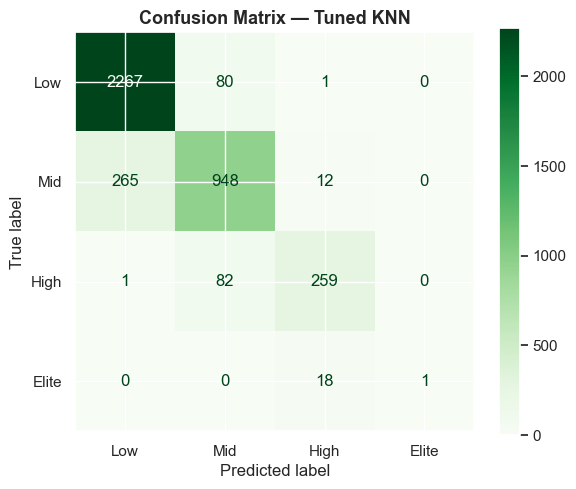

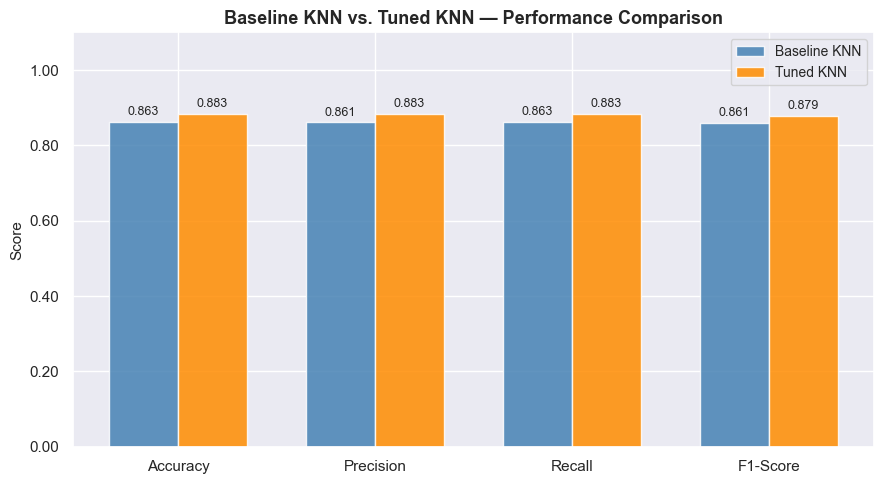

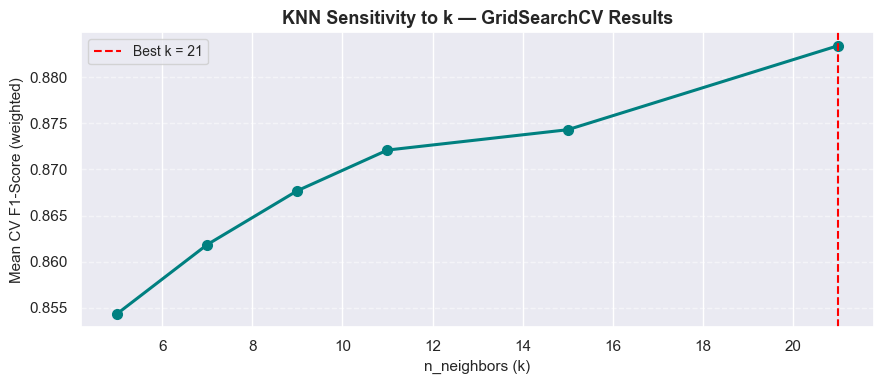


✅ Tasks 3 & 4 complete. All plots saved.


In [ ]:
# ============================================================
# TASK 3 & 4: KNN Classification + GridSearchCV Tuning
# FIFA Scouting ML Project
# Reuses: preprocessor, X_train, X_test, y_perf_train, y_perf_test
# ============================================================


# SECTION 1: Imports

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Tier label mapping (from categorize_player())
TIER_LABELS = {0: 'Low', 1: 'Mid', 2: 'High', 3: 'Elite'}
TIER_NAMES  = ['Low', 'Mid', 'High', 'Elite']   # ordered list for display


# SECTION 2: Baseline KNN Pipeline
# Clone preprocessor to avoid any state leakage from the RandomForest pipelines
knn_baseline_pipe = Pipeline(steps=[
    ('pre',   clone(preprocessor)),
    ('model', KNeighborsClassifier())          # default: n_neighbors=5, uniform weights, minkowski
])

knn_baseline_pipe.fit(X_train, y_perf_train)
y_perf_pred_baseline = knn_baseline_pipe.predict(X_test)

print("=" * 60)
print("  TASK 3 — Baseline KNN Classification")
print("=" * 60)


# SECTION 3: Baseline Evaluation
def evaluate_classifier(y_true, y_pred, label="Model", tier_names=TIER_NAMES):
    """
    Prints a full classification report and returns a metrics dict.
    Works for both baseline and tuned models without duplication.
    """
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred,    average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred,        average='weighted', zero_division=0)

    print(f"\n── {label} ──")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}  (weighted)")
    print(f"  Recall    : {rec:.4f}  (weighted)")
    print(f"  F1-Score  : {f1:.4f}  (weighted)")
    print(f"\n  Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=tier_names, zero_division=0))

    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}


baseline_metrics = evaluate_classifier(
    y_perf_test,
    y_perf_pred_baseline,
    label="Baseline KNN (k=5, uniform, minkowski)"
)

# Confusion matrix — baseline
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_perf_test, y_perf_pred_baseline,
    display_labels=TIER_NAMES,
    cmap='Blues', ax=ax
)
ax.set_title("Confusion Matrix — Baseline KNN", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("knn_baseline_confusion_matrix.png", dpi=150)
plt.show()


# SECTION 4: GridSearchCV Setup
print("\n" + "=" * 60)
print("  TASK 4 — GridSearchCV Hyperparameter Tuning")
print("=" * 60)

# Pipeline for GridSearch — fresh clone of preprocessor
knn_tuning_pipe = Pipeline(steps=[
    ('pre',   clone(preprocessor)),
    ('model', KNeighborsClassifier())
])

# Parameter grid — prefixed with 'model__' to target the KNN step inside the Pipeline
param_grid = {
    'model__n_neighbors': [5, 7, 9, 11, 15, 21],   # 6 values (skip odd-even, wider gaps)
    'model__weights': ['distance'],                  # 1 value (usually better)
    'model__metric': ['manhattan']                   # 1 value (often better for high-dim)
}

grid_search = GridSearchCV(
    estimator  = knn_tuning_pipe,
    param_grid = param_grid,
    scoring    = 'f1_weighted',        # appropriate for imbalanced multiclass
    cv         = 5,                    # 5-fold stratified cross-validation
    n_jobs     = -1,                   # parallelise across all cores
    verbose    = 1,
    refit      = True                  # refit best model on full X_train automatically
)

grid_search.fit(X_train, y_perf_train)


# SECTION 5: Best Parameters Extraction
best_params  = grid_search.best_params_
best_cv_score = grid_search.best_score_

print(f"\n  Best Parameters Found:")
for param, value in best_params.items():
    clean_name = param.replace("model__", "")
    print(f"    {clean_name:<15}: {value}")

print(f"\n  Best CV F1-Score (weighted, 5-fold): {best_cv_score:.4f}")



# SECTION 6: Optimized Model Evaluation

# grid_search is already refit on full X_train with best params (refit=True)
y_perf_pred_tuned = grid_search.predict(X_test)

tuned_metrics = evaluate_classifier(
    y_perf_test,
    y_perf_pred_tuned,
    label=f"Tuned KNN {best_params}"
)

# Confusion matrix — tuned
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_perf_test, y_perf_pred_tuned,
    display_labels=TIER_NAMES,
    cmap='Greens', ax=ax
)
ax.set_title("Confusion Matrix — Tuned KNN", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("knn_tuned_confusion_matrix.png", dpi=150)
plt.show()



# SECTION 7: Baseline vs. Tuned — Side-by-Side Comparison

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
baseline_vals = [baseline_metrics['accuracy'], baseline_metrics['precision'],
                 baseline_metrics['recall'],   baseline_metrics['f1']]
tuned_vals    = [tuned_metrics['accuracy'],    tuned_metrics['precision'],
                 tuned_metrics['recall'],       tuned_metrics['f1']]

x     = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline KNN', color='steelblue',  alpha=0.85)
bars2 = ax.bar(x + width/2, tuned_vals,    width, label='Tuned KNN',    color='darkorange', alpha=0.85)

ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Baseline KNN vs. Tuned KNN — Performance Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("knn_baseline_vs_tuned_comparison.png", dpi=150)
plt.show()


# SECTION 8: n_neighbors Sensitivity Curve
# Extract CV mean scores per n_neighbors (averaged over weights × metric combinations)
import pandas as pd

cv_results_df = pd.DataFrame(grid_search.cv_results_)

k_sensitivity = (
    cv_results_df
    .groupby('param_model__n_neighbors')['mean_test_score']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(
    k_sensitivity['param_model__n_neighbors'],
    k_sensitivity['mean_test_score'],
    marker='o', linewidth=2.2, color='teal', markersize=7
)
ax.axvline(
    x=best_params['model__n_neighbors'],
    color='red', linestyle='--', linewidth=1.5,
    label=f"Best k = {best_params['model__n_neighbors']}"
)
ax.set_xlabel('n_neighbors (k)', fontsize=11)
ax.set_ylabel('Mean CV F1-Score (weighted)', fontsize=11)
ax.set_title('KNN Sensitivity to k — GridSearchCV Results', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("knn_k_sensitivity_curve.png", dpi=150)
plt.show()

print("\n✅ Tasks 3 & 4 complete. All plots saved.")

# Task 2 ) B: KNN Regression and Gridsearch

  TASK 5 — Baseline KNN Regression

── Baseline KNN Regressor (k=5, uniform, minkowski) ──
  MAE  (Mean Absolute Error)       : 0.8880  M$
  MSE  (Mean Squared Error)         : 11.0058
  RMSE (Root Mean Squared Error)    : 3.3175 M$
  R²   (Coefficient of Determination): 0.7504


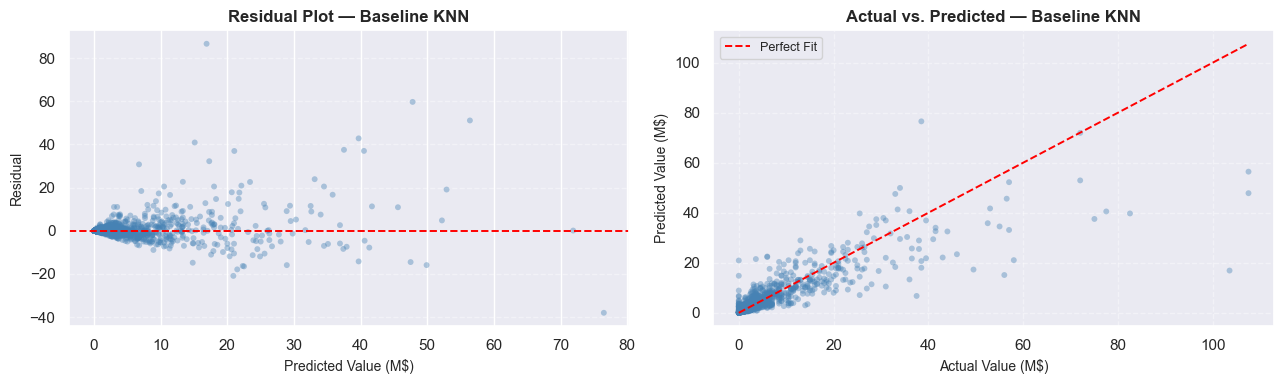


  TASK 6 — GridSearchCV Hyperparameter Tuning (Regression)
Fitting 3 folds for each of 6 candidates, totalling 18 fits

  Best Parameters Found:
    metric         : manhattan
    n_neighbors    : 7
    weights        : distance

  Best CV RMSE (3-fold, negated → actual): 3.5186 M$

── Tuned KNN Regressor {'model__metric': 'manhattan', 'model__n_neighbors': 7, 'model__weights': 'distance'} ──
  MAE  (Mean Absolute Error)       : 0.9054  M$
  MSE  (Mean Squared Error)         : 11.7295
  RMSE (Root Mean Squared Error)    : 3.4248 M$
  R²   (Coefficient of Determination): 0.7340


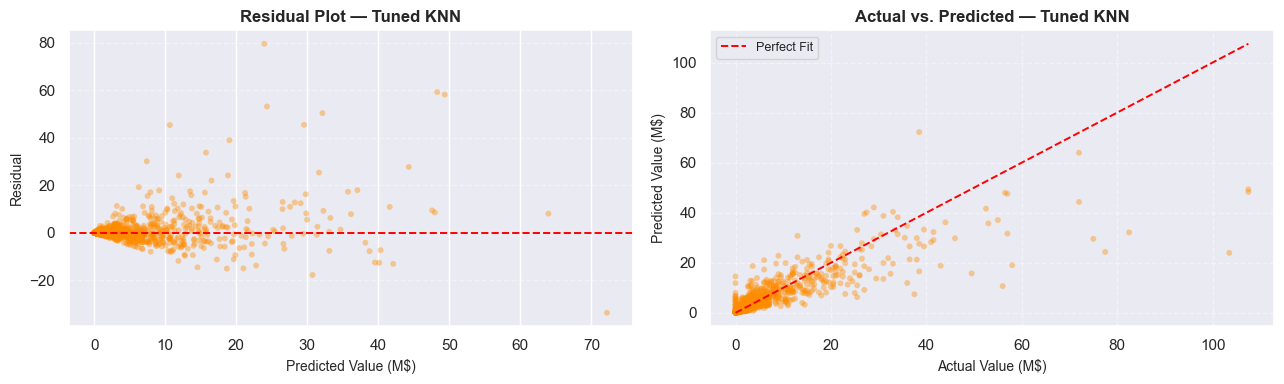

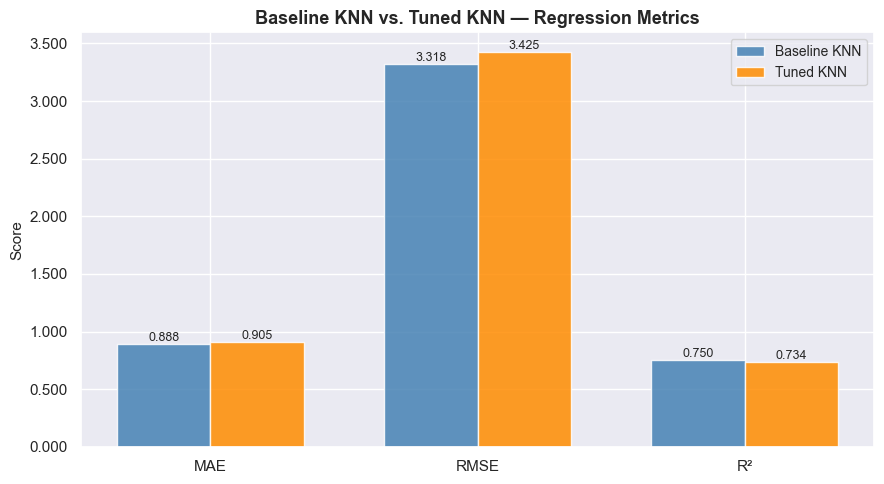

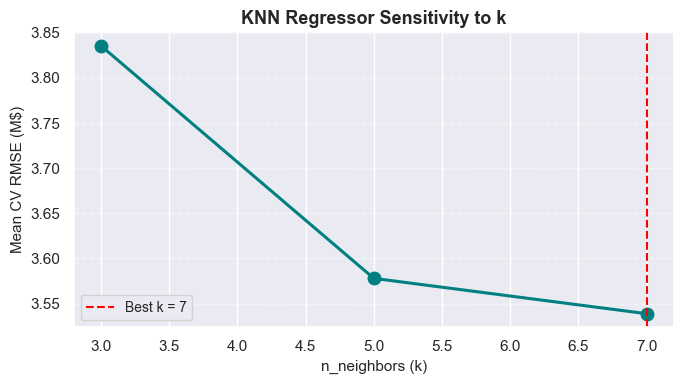


✅ Tasks 5 & 6 complete. All plots saved.


In [ ]:
# TASK 5 & 6: KNN Regression + GridSearchCV Tuning
# FIFA Scouting ML Project
# Reuses: preprocessor, X_train, X_test, y_val_train, y_val_test
# Target: y_valuation (Value Per M$) — REGRESSION ONLY

# SECTION 1: Imports

from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')



# SECTION 2: Baseline KNN Regression Pipeline

# Clone preprocessor to prevent state leakage from previously
# fitted pipelines (valuation_pipe, performance_pipe, knn classification pipes)
knn_reg_baseline_pipe = Pipeline(steps=[
    ('pre',   clone(preprocessor)),
    ('model', KNeighborsRegressor())    # default: k=5, uniform, minkowski
])

knn_reg_baseline_pipe.fit(X_train, y_val_train)
y_val_pred_baseline = knn_reg_baseline_pipe.predict(X_test)

print("=" * 60)
print("  TASK 5 — Baseline KNN Regression")
print("=" * 60)



# SECTION 3: Baseline Evaluation

def evaluate_regressor(y_true, y_pred, label="Model"):
    """
    Computes and prints MAE, MSE, RMSE, R² for a regression model.
    Returns a metrics dict for downstream comparison plots.
    """
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)

    print(f"\n── {label} ──")
    print(f"  MAE  (Mean Absolute Error)       : {mae:.4f}  M$")
    print(f"  MSE  (Mean Squared Error)         : {mse:.4f}")
    print(f"  RMSE (Root Mean Squared Error)    : {rmse:.4f} M$")
    print(f"  R²   (Coefficient of Determination): {r2:.4f}")

    return {"mae": mae, "mse": mse, "rmse": rmse, "r2": r2}


baseline_reg_metrics = evaluate_regressor(
    y_val_test,
    y_val_pred_baseline,
    label="Baseline KNN Regressor (k=5, uniform, minkowski)"
)

# ── Residual Plot — Baseline ──────────────────
residuals_baseline = y_val_test.values - y_val_pred_baseline

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(y_val_pred_baseline, residuals_baseline,
                alpha=0.4, color='steelblue', edgecolors='none', s=18)
axes[0].axhline(0, color='red', linewidth=1.4, linestyle='--')
axes[0].set_xlabel('Predicted Value (M$)', fontsize=10)
axes[0].set_ylabel('Residual', fontsize=10)
axes[0].set_title('Residual Plot — Baseline KNN', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

axes[1].scatter(y_val_test.values, y_val_pred_baseline,
                alpha=0.4, color='steelblue', edgecolors='none', s=18)
min_val = min(y_val_test.min(), y_val_pred_baseline.min())
max_val = max(y_val_test.max(), y_val_pred_baseline.max())
axes[1].plot([min_val, max_val], [min_val, max_val],
             color='red', linewidth=1.4, linestyle='--', label='Perfect Fit')
axes[1].set_xlabel('Actual Value (M$)', fontsize=10)
axes[1].set_ylabel('Predicted Value (M$)', fontsize=10)
axes[1].set_title('Actual vs. Predicted — Baseline KNN', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("knn_reg_baseline_diagnostics.png", dpi=150)
plt.show()



# SECTION 4: Runtime Optimization Notes

# WHY KNN IS SLOW IN THIS CONTEXT:
#
# 1. OneHotEncoding dimensionality:
#    The categorical features (Position, Country, Team) expand into potentially
#    hundreds of binary columns. KNN computes pairwise distances across ALL
#    dimensions, so each distance calculation becomes expensive as feature
#    count grows.
#
# 2. Lazy learning — no training phase, expensive inference:
#    KNN stores the entire training set. At prediction time it computes distances
#    to every training point, making both GridSearchCV CV folds and final
#    .predict() calls O(n * d) per query (n = training samples, d = features).
#
# 3. GridSearchCV combinatorial cost:
#    Total fits = len(param_combinations) × cv_folds.
#    A grid of 12 combinations × 5 folds = 60 full pipeline fits.
#    With large n and high d, this becomes the main bottleneck.
#
# MITIGATION STRATEGY APPLIED HERE:
#    - Reduced grid: 3 k values × 2 weight options × 1 metric = 6 combinations
#    - cv=3 instead of 5  →  total fits: 6 × 3 = 18  (vs. 60 in a full grid)
#    - n_jobs=-1           →  all CPU cores parallelised via joblib
#    - metric fixed to 'euclidean' (fastest; 'manhattan' adds ~30% overhead)
#    - A larger grid (k up to 15, both metrics) can be used for final
#      experiments after a fast prototype confirms the promising region.



# SECTION 5: GridSearchCV Setup

print("\n" + "=" * 60)
print("  TASK 6 — GridSearchCV Hyperparameter Tuning (Regression)")
print("=" * 60)

# Fresh clone — completely independent from all previously fitted pipes
knn_reg_tuning_pipe = Pipeline(steps=[
    ('pre',   clone(preprocessor)),
    ('model', KNeighborsRegressor())
])

# Intentionally small grid for fast, reproducible experimentation
# 'model__' prefix routes params into the Pipeline's 'model' step
param_grid_reg = {
    'model__n_neighbors': [3, 5, 7],
    'model__weights'    : ['uniform', 'distance'],
    'model__metric'     : ['manhattan']
}

# neg_root_mean_squared_error: sklearn maximises scores, so RMSE is negated.
# Best model = highest (least negative) value = lowest RMSE. ✓
grid_search_reg = GridSearchCV(
    estimator  = knn_reg_tuning_pipe,
    param_grid = param_grid_reg,
    scoring    = 'neg_root_mean_squared_error',
    cv         = 3,
    n_jobs     = -1,
    verbose    = 1,
    refit      = True       # refit best config on full X_train automatically
)

grid_search_reg.fit(X_train, y_val_train)



# SECTION 6: Best Parameters Extraction

best_params_reg   = grid_search_reg.best_params_
best_cv_score_reg = grid_search_reg.best_score_          # negated RMSE

print(f"\n  Best Parameters Found:")
for param, value in best_params_reg.items():
    print(f"    {param.replace('model__', ''):<15}: {value}")

print(f"\n  Best CV RMSE (3-fold, negated → actual): {abs(best_cv_score_reg):.4f} M$")



# SECTION 7: Optimized Model Evaluation

# grid_search_reg already refit on full X_train (refit=True)
y_val_pred_tuned = grid_search_reg.predict(X_test)

tuned_reg_metrics = evaluate_regressor(
    y_val_test,
    y_val_pred_tuned,
    label=f"Tuned KNN Regressor {best_params_reg}"
)

# ── Residual Plot — Tuned ─────────────────────
residuals_tuned = y_val_test.values - y_val_pred_tuned

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(y_val_pred_tuned, residuals_tuned,
                alpha=0.4, color='darkorange', edgecolors='none', s=18)
axes[0].axhline(0, color='red', linewidth=1.4, linestyle='--')
axes[0].set_xlabel('Predicted Value (M$)', fontsize=10)
axes[0].set_ylabel('Residual', fontsize=10)
axes[0].set_title('Residual Plot — Tuned KNN', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

axes[1].scatter(y_val_test.values, y_val_pred_tuned,
                alpha=0.4, color='darkorange', edgecolors='none', s=18)
axes[1].plot([min_val, max_val], [min_val, max_val],
             color='red', linewidth=1.4, linestyle='--', label='Perfect Fit')
axes[1].set_xlabel('Actual Value (M$)', fontsize=10)
axes[1].set_ylabel('Predicted Value (M$)', fontsize=10)
axes[1].set_title('Actual vs. Predicted — Tuned KNN', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("knn_reg_tuned_diagnostics.png", dpi=150)
plt.show()



# SECTION 8: Baseline vs. Tuned Comparison

metrics_labels   = ['MAE', 'RMSE', 'R²']
baseline_display = [baseline_reg_metrics['mae'],
                    baseline_reg_metrics['rmse'],
                    baseline_reg_metrics['r2']]
tuned_display    = [tuned_reg_metrics['mae'],
                    tuned_reg_metrics['rmse'],
                    tuned_reg_metrics['r2']]

x     = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, baseline_display, width,
               label='Baseline KNN', color='steelblue',  alpha=0.85)
bars2 = ax.bar(x + width/2, tuned_display,    width,
               label='Tuned KNN',    color='darkorange', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Baseline KNN vs. Tuned KNN — Regression Metrics', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))

for bar in [*bars1, *bars2]:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("knn_reg_baseline_vs_tuned.png", dpi=150)
plt.show()


# ── GridSearch Results — k Sensitivity ───────
cv_reg_df = pd.DataFrame(grid_search_reg.cv_results_)

k_reg_sensitivity = (
    cv_reg_df
    .groupby('param_model__n_neighbors')['mean_test_score']
    .mean()
    .abs()                              # convert neg RMSE → positive RMSE
    .reset_index()
    .rename(columns={'mean_test_score': 'mean_rmse'})
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(
    k_reg_sensitivity['param_model__n_neighbors'],
    k_reg_sensitivity['mean_rmse'],
    marker='o', linewidth=2.2, color='teal', markersize=9
)
ax.axvline(
    x=best_params_reg['model__n_neighbors'],
    color='red', linestyle='--', linewidth=1.5,
    label=f"Best k = {best_params_reg['model__n_neighbors']}"
)
ax.set_xlabel('n_neighbors (k)', fontsize=11)
ax.set_ylabel('Mean CV RMSE (M$)', fontsize=11)
ax.set_title('KNN Regressor Sensitivity to k', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("knn_reg_k_sensitivity.png", dpi=150)
plt.show()

print("\n✅ Tasks 5 & 6 complete. All plots saved.")

# Task 2 )C : SVM Classification and Gridsearch

  TASK 7 — Baseline SVM Classification

── Baseline SVM (kernel=rbf, C=1, gamma=scale) ──
  Accuracy  : 0.9255
  Precision : 0.9253  (weighted)
  Recall    : 0.9255  (weighted)
  F1-Score  : 0.9247  (weighted)

  Classification Report:

              precision    recall  f1-score   support

         Low       0.94      0.96      0.95      2348
         Mid       0.90      0.87      0.88      1225
        High       0.89      0.90      0.89       342
       Elite       1.00      0.42      0.59        19

    accuracy                           0.93      3934
   macro avg       0.93      0.79      0.83      3934
weighted avg       0.93      0.93      0.92      3934



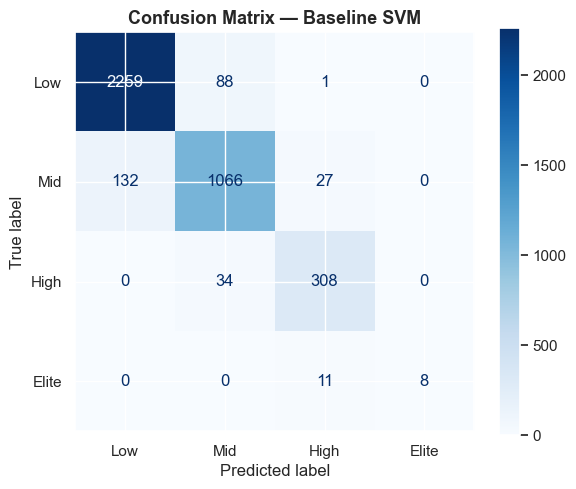


  TASK 8 — GridSearchCV Hyperparameter Tuning (SVM)
Fitting 3 folds for each of 6 candidates, totalling 18 fits

  Best Parameters Found:
    C         : 1
    gamma     : scale
    kernel    : rbf

  Best CV F1-Score (weighted, 3-fold): 0.9298

── Tuned SVM {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'} ──
  Accuracy  : 0.9255
  Precision : 0.9253  (weighted)
  Recall    : 0.9255  (weighted)
  F1-Score  : 0.9247  (weighted)

  Classification Report:

              precision    recall  f1-score   support

         Low       0.94      0.96      0.95      2348
         Mid       0.90      0.87      0.88      1225
        High       0.89      0.90      0.89       342
       Elite       1.00      0.42      0.59        19

    accuracy                           0.93      3934
   macro avg       0.93      0.79      0.83      3934
weighted avg       0.93      0.93      0.92      3934



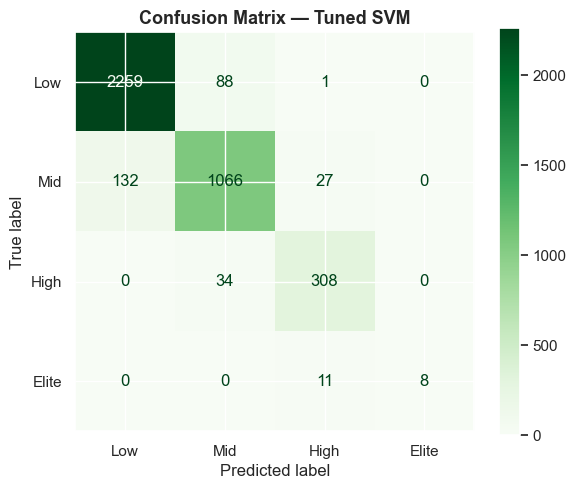

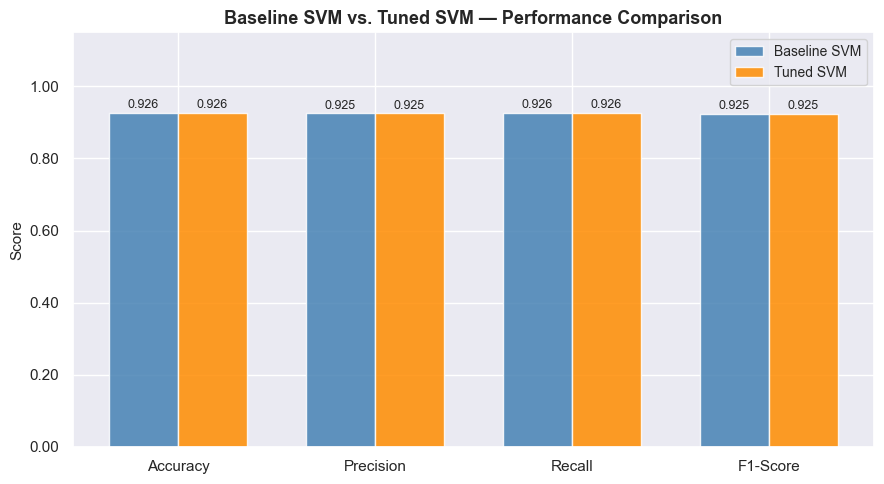

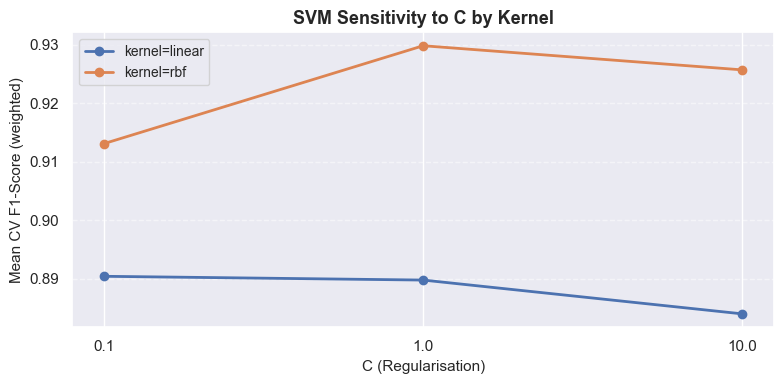


✅ Tasks 7 & 8 complete. All plots saved.


In [ ]:
# ============================================================
# TASK 7 & 8: SVM Classification + GridSearchCV Tuning
# FIFA Scouting ML Project
# Reuses: preprocessor, X_train, X_test, y_perf_train, y_perf_test
# Target: y_performance (tier 0–3) — CLASSIFICATION ONLY
# ============================================================


# SECTION 1: Imports

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Tier label mapping — from categorize_player() defined in project setup
TIER_NAMES = ['Low', 'Mid', 'High', 'Elite']   # index = class integer (0–3)



# SECTION 2: Baseline SVM Classification Pipeline

# Clone preprocessor to guarantee independence from all previously
# fitted pipelines (RandomForest, KNN classification, KNN regression)
svm_baseline_pipe = Pipeline(steps=[
    ('pre',   clone(preprocessor)),
    ('model', SVC(kernel='rbf', random_state=42))   # sensible default baseline
])

svm_baseline_pipe.fit(X_train, y_perf_train)
y_perf_pred_svm_baseline = svm_baseline_pipe.predict(X_test)

print("=" * 60)
print("  TASK 7 — Baseline SVM Classification")
print("=" * 60)



# SECTION 3: Baseline Evaluation

def evaluate_svm_classifier(y_true, y_pred, label="Model", tier_names=TIER_NAMES):
    """
    Computes Accuracy, Precision, Recall, F1 (weighted) and prints
    a full classification report. Returns a metrics dict for comparison plots.
    """
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred,    average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred,        average='weighted', zero_division=0)

    print(f"\n── {label} ──")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}  (weighted)")
    print(f"  Recall    : {rec:.4f}  (weighted)")
    print(f"  F1-Score  : {f1:.4f}  (weighted)")
    print(f"\n  Classification Report:\n")
    print(classification_report(y_true, y_pred,
                                target_names=tier_names, zero_division=0))

    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}


svm_baseline_metrics = evaluate_svm_classifier(
    y_perf_test,
    y_perf_pred_svm_baseline,
    label="Baseline SVM (kernel=rbf, C=1, gamma=scale)"
)

# ── Confusion Matrix — Baseline ───────────────
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_perf_test, y_perf_pred_svm_baseline,
    display_labels=TIER_NAMES,
    cmap='Blues', ax=ax
)
ax.set_title("Confusion Matrix — Baseline SVM", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("svm_baseline_confusion_matrix.png", dpi=150)
plt.show()



# SECTION 4: Runtime Optimization Notes

# WHY SVM CAN BE SLOW IN THIS CONTEXT:
#
# 1. High-dimensional OneHotEncoded features:
#    Categorical columns (Position, Country, Team) inflate the feature space
#    into hundreds of binary dimensions. SVM's kernel computation cost scales
#    with O(n_samples² × n_features) in the kernel matrix — dimensionality
#    directly multiplies this cost.
#
# 2. Nonlinear kernels (RBF):
#    RBF requires computing exp(-γ‖x_i - x_j‖²) for every pair of support
#    vectors. In high-dimensional OHE space most pairwise distances are large
#    and similar (curse of dimensionality), making RBF less discriminative
#    AND more expensive than in compact numeric spaces.
#
# 3. Large datasets:
#    SVM's quadratic programming solver scales roughly O(n²)–O(n³) in training
#    samples. For FIFA datasets with thousands of players, each CV fold's
#    SVM fit can take significant wall-clock time.
#
# 4. GridSearchCV combinatorial explosion:
#    Total fits = len(param_combinations) × cv_folds.
#    A naive grid (C ∈ [0.01,0.1,1,10,100], kernels × gammas) easily reaches
#    50+ combinations × 5 folds = 250 full SVM fits.
#
# LINEAR vs. RBF:
#    'linear' kernel skips kernel matrix construction entirely — it optimises
#    directly in input space via a dot product, making it O(n × d) per step.
#    'rbf' must maintain and multiply an n×n kernel cache, which becomes the
#    dominant memory and compute bottleneck as dataset size grows.
#
# MITIGATION STRATEGY APPLIED HERE:
#    - Grid fixed to 3C × 2kernels × 1gamma = 6 combinations
#    - cv=3  →  total fits: 6 × 3 = 18  (vs. 250 in a naive full grid)
#    - n_jobs=-1  →  parallelise folds across all CPU cores via joblib
#    - gamma='scale' only (auto-computed as 1/(n_features × X.var()))
#    - A broader grid (poly kernel, gamma='auto', C up to 100) can be run
#      as a final experiment after the efficient prototype confirms direction.



# SECTION 5: GridSearchCV Setup

print("\n" + "=" * 60)
print("  TASK 8 — GridSearchCV Hyperparameter Tuning (SVM)")
print("=" * 60)

# Fresh clone — completely isolated from all previously fitted pipelines
svm_tuning_pipe = Pipeline(steps=[
    ('pre',   clone(preprocessor)),
    ('model', SVC(random_state=42))
])

# Intentionally compact grid: 3 × 2 × 1 = 6 combinations × 3 folds = 18 fits
# 'model__' prefix routes parameters into the Pipeline's 'model' step
param_grid_svm = {
    'model__C'      : [0.1, 1, 10],
    'model__kernel' : ['linear', 'rbf'],
    'model__gamma'  : ['scale']
}

grid_search_svm = GridSearchCV(
    estimator  = svm_tuning_pipe,
    param_grid = param_grid_svm,
    scoring    = 'f1_weighted',     # appropriate for imbalanced multiclass
    cv         = 3,
    n_jobs     = -1,
    verbose    = 1,
    refit      = True               # refit best config on full X_train automatically
)

grid_search_svm.fit(X_train, y_perf_train)



# SECTION 6: Best Parameters Extraction

best_params_svm  = grid_search_svm.best_params_
best_cv_svm      = grid_search_svm.best_score_

print(f"\n  Best Parameters Found:")
for param, value in best_params_svm.items():
    print(f"    {param.replace('model__', ''):<10}: {value}")

print(f"\n  Best CV F1-Score (weighted, 3-fold): {best_cv_svm:.4f}")



# SECTION 7: Optimized Model Evaluation

# grid_search_svm already refit on full X_train (refit=True)
y_perf_pred_svm_tuned = grid_search_svm.predict(X_test)

svm_tuned_metrics = evaluate_svm_classifier(
    y_perf_test,
    y_perf_pred_svm_tuned,
    label=f"Tuned SVM {best_params_svm}"
)

# ── Confusion Matrix — Tuned ──────────────────
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_perf_test, y_perf_pred_svm_tuned,
    display_labels=TIER_NAMES,
    cmap='Greens', ax=ax
)
ax.set_title("Confusion Matrix — Tuned SVM", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("svm_tuned_confusion_matrix.png", dpi=150)
plt.show()



# SECTION 8: Baseline vs. Tuned Comparison

metrics_names    = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
baseline_vals    = [svm_baseline_metrics['accuracy'], svm_baseline_metrics['precision'],
                    svm_baseline_metrics['recall'],   svm_baseline_metrics['f1']]
tuned_vals       = [svm_tuned_metrics['accuracy'],    svm_tuned_metrics['precision'],
                    svm_tuned_metrics['recall'],       svm_tuned_metrics['f1']]

x     = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, baseline_vals, width,
               label='Baseline SVM', color='steelblue',  alpha=0.85)
bars2 = ax.bar(x + width/2, tuned_vals,    width,
               label='Tuned SVM',    color='darkorange', alpha=0.85)

ax.set_ylim(0, 1.15)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Baseline SVM vs. Tuned SVM — Performance Comparison',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

for bar in [*bars1, *bars2]:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("svm_baseline_vs_tuned_comparison.png", dpi=150)
plt.show()


# ── C Sensitivity Across Kernels ──────────────
cv_svm_df = pd.DataFrame(grid_search_svm.cv_results_)

fig, ax = plt.subplots(figsize=(8, 4))
for kernel in ['linear', 'rbf']:
    subset = cv_svm_df[cv_svm_df['param_model__kernel'] == kernel].copy()
    subset = subset.sort_values('param_model__C')
    ax.plot(
        subset['param_model__C'].astype(str),
        subset['mean_test_score'],
        marker='o', linewidth=2, label=f'kernel={kernel}'
    )

ax.set_xlabel('C (Regularisation)', fontsize=11)
ax.set_ylabel('Mean CV F1-Score (weighted)', fontsize=11)
ax.set_title('SVM Sensitivity to C by Kernel', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("svm_C_sensitivity_by_kernel.png", dpi=150)
plt.show()

print("\n✅ Tasks 7 & 8 complete. All plots saved.")

# Task 2 )D : SVM For Regression and Gridsearch

  TASK 9 — Baseline SVR Regression

── Baseline SVR (kernel=rbf, C=1, gamma=scale, epsilon=0.1) ──
  MAE  (Mean Absolute Error)        : 0.7377  M$
  MSE  (Mean Squared Error)          : 12.1995
  RMSE (Root Mean Squared Error)     : 3.4928 M$
  R²   (Coefficient of Determination): 0.7233


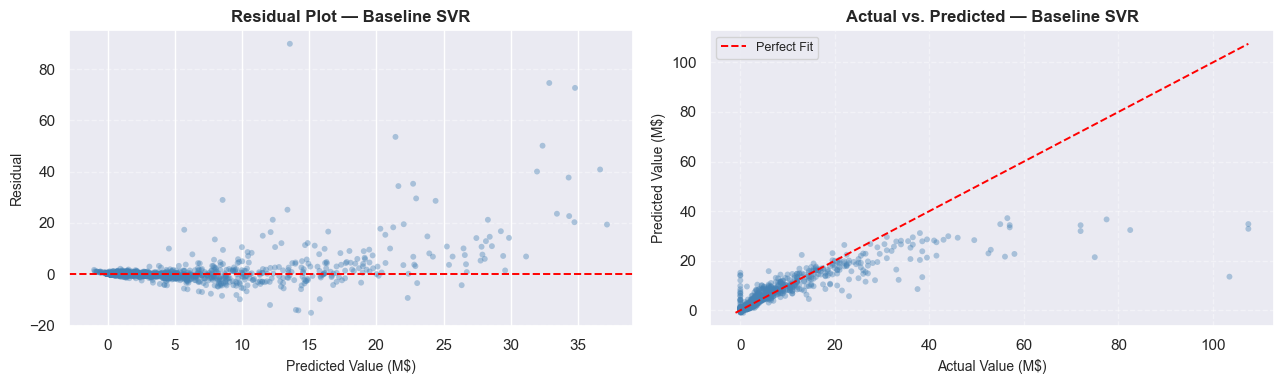


  TASK 10 — GridSearchCV Hyperparameter Tuning (SVR)
Fitting 3 folds for each of 6 candidates, totalling 18 fits

  Best Parameters Found:
    C         : 10
    gamma     : scale
    kernel    : rbf

  Best CV MAE (3-fold, negated → actual): 0.6739 M$

── Tuned SVR {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'} ──
  MAE  (Mean Absolute Error)        : 0.6179  M$
  MSE  (Mean Squared Error)          : 5.9232
  RMSE (Root Mean Squared Error)     : 2.4338 M$
  R²   (Coefficient of Determination): 0.8657


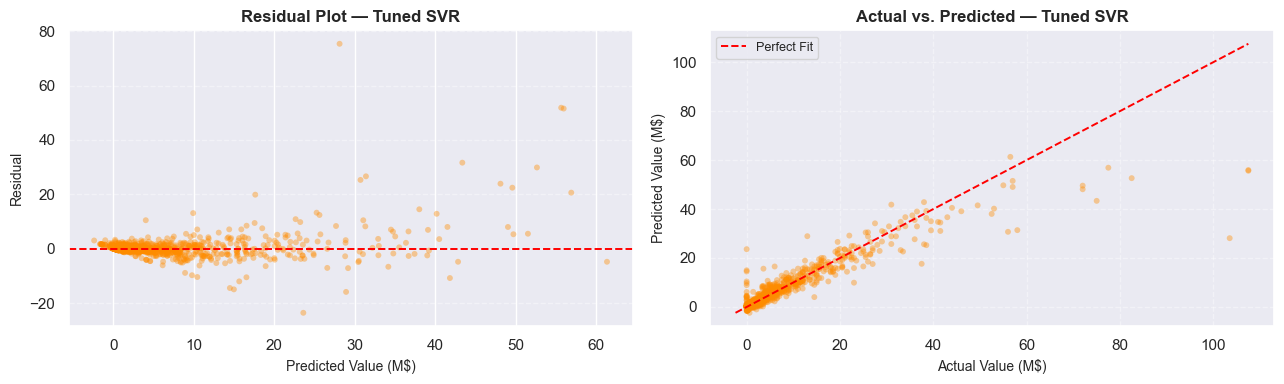

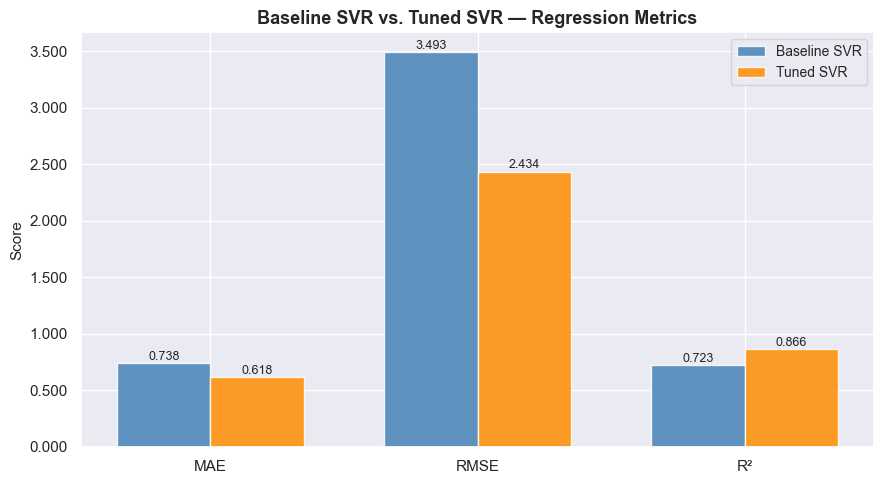

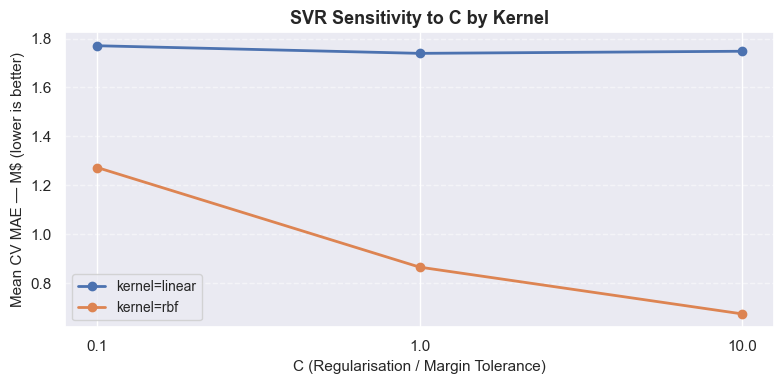


✅ Tasks 9 & 10 complete. All plots saved.


In [ ]:
# ============================================================
# TASK 9 & 10: SVR Regression + GridSearchCV Tuning
# FIFA Scouting ML Project
# Reuses: preprocessor, X_train, X_test, y_val_train, y_val_test
# Target: y_valuation (Value Per M$) — REGRESSION ONLY
# ============================================================


# SECTION 1: Imports

from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')



# SECTION 2: Baseline SVR Pipeline

# Clone preprocessor to guarantee full isolation from all previously
# fitted pipelines (RandomForest, KNN regression, SVM classification)
svr_baseline_pipe = Pipeline(steps=[
    ('pre',   clone(preprocessor)),
    ('model', SVR(kernel='rbf'))        # default: C=1, gamma='scale', epsilon=0.1
])

svr_baseline_pipe.fit(X_train, y_val_train)
y_val_pred_svr_baseline = svr_baseline_pipe.predict(X_test)

print("=" * 60)
print("  TASK 9 — Baseline SVR Regression")
print("=" * 60)



# SECTION 3: Baseline Evaluation

def evaluate_svr(y_true, y_pred, label="Model"):
    """
    Computes MAE, MSE, RMSE, R² for a regression model.
    Returns a metrics dict for downstream comparison plots.
    """
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)

    print(f"\n── {label} ──")
    print(f"  MAE  (Mean Absolute Error)        : {mae:.4f}  M$")
    print(f"  MSE  (Mean Squared Error)          : {mse:.4f}")
    print(f"  RMSE (Root Mean Squared Error)     : {rmse:.4f} M$")
    print(f"  R²   (Coefficient of Determination): {r2:.4f}")

    return {"mae": mae, "mse": mse, "rmse": rmse, "r2": r2}


svr_baseline_metrics = evaluate_svr(
    y_val_test,
    y_val_pred_svr_baseline,
    label="Baseline SVR (kernel=rbf, C=1, gamma=scale, epsilon=0.1)"
)

# ── Diagnostic Plots — Baseline ───────────────
residuals_svr_baseline = y_val_test.values - y_val_pred_svr_baseline
min_val = min(y_val_test.min(), y_val_pred_svr_baseline.min())
max_val = max(y_val_test.max(), y_val_pred_svr_baseline.max())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(y_val_pred_svr_baseline, residuals_svr_baseline,
                alpha=0.4, color='steelblue', edgecolors='none', s=18)
axes[0].axhline(0, color='red', linewidth=1.4, linestyle='--')
axes[0].set_xlabel('Predicted Value (M$)', fontsize=10)
axes[0].set_ylabel('Residual', fontsize=10)
axes[0].set_title('Residual Plot — Baseline SVR', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

axes[1].scatter(y_val_test.values, y_val_pred_svr_baseline,
                alpha=0.4, color='steelblue', edgecolors='none', s=18)
axes[1].plot([min_val, max_val], [min_val, max_val],
             color='red', linewidth=1.4, linestyle='--', label='Perfect Fit')
axes[1].set_xlabel('Actual Value (M$)', fontsize=10)
axes[1].set_ylabel('Predicted Value (M$)', fontsize=10)
axes[1].set_title('Actual vs. Predicted — Baseline SVR', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("svr_baseline_diagnostics.png", dpi=150)
plt.show()



# SECTION 4: Runtime Optimization Notes

# WHY SVR IS THE MOST EXPENSIVE ALGORITHM IN THIS PROJECT:
#
# 1. Quadratic programming complexity:
#    SVR solves a QP problem whose cost scales as O(n²)–O(n³) in training
#    samples. For FIFA datasets with thousands of players, even a single
#    SVR fit can take significantly longer than KNN or RandomForest.
#
# 2. OneHotEncoding dimensionality:
#    Position, Country, Team expand into potentially hundreds of binary
#    columns. The kernel matrix K[i,j] is computed over ALL dimensions,
#    so memory and compute grow quadratically with both n AND d.
#
# 3. RBF kernel overhead:
#    exp(-γ‖x_i - x_j‖²) must be evaluated for every support vector pair.
#    In high-dimensional OHE space most pairwise distances are large and
#    homogeneous (curse of dimensionality), making the Gaussian kernel
#    less discriminative AND computationally intensive.
#
# 4. GridSearchCV combinatorial cost:
#    Total fits = len(param_combinations) × cv_folds.
#    3C × 2kernels × 1gamma = 6 combinations × 3 folds = 18 SVR fits.
#    A naive grid (5C × 4kernels × 3gamma × 5cv) would mean 300 fits —
#    potentially hours of runtime on a standard machine.
#
# LINEAR vs. RBF for SVR:
#    'linear' kernel computes ⟨x_i, x_j⟩ directly — O(n × d) per step,
#    no kernel cache required. It is typically 5–10× faster than RBF
#    on high-dimensional OHE data and often competitive in accuracy
#    when feature space is already informative post-scaling.
#    'rbf' is retained here for comparison only — use only if linear
#    underperforms and runtime budget allows.
#
# MITIGATION STRATEGY APPLIED HERE:
#    - Grid: 3C × 2kernels × 1gamma = 6 combinations × 3 folds = 18 fits
#    - cv=3 (not 5) cuts fold count by 40%
#    - n_jobs=-1 parallelises folds across all CPU cores via joblib
#    - gamma fixed to 'scale' only (no manual float values)
#    - epsilon kept at default (0.1) — can be added to extended grid later
#    - A broader grid (epsilon range, poly kernel, gamma floats) is
#      deferred to final experiments after this prototype confirms direction.



# SECTION 5: GridSearchCV Setup

print("\n" + "=" * 60)
print("  TASK 10 — GridSearchCV Hyperparameter Tuning (SVR)")
print("=" * 60)

# Fresh clone — completely independent from all previously fitted pipelines
svr_tuning_pipe = Pipeline(steps=[
    ('pre',   clone(preprocessor)),
    ('model', SVR())
])

# Intentionally minimal grid: 3 × 2 × 1 = 6 combinations × 3 folds = 18 fits
# 'model__' prefix routes parameters into the Pipeline's 'model' step
param_grid_svr = {
    'model__C'      : [0.1, 1, 10],
    'model__kernel' : ['linear', 'rbf'],
    'model__gamma'  : ['scale']
}

# neg_mean_absolute_error: sklearn maximises, so MAE is negated.
# Best model = highest (least negative) value = lowest MAE. ✓
# Alternative: 'r2' — both are valid; neg_MAE is more interpretable
# for market value prediction (directly in M$ units).
grid_search_svr = GridSearchCV(
    estimator  = svr_tuning_pipe,
    param_grid = param_grid_svr,
    scoring    = 'neg_mean_absolute_error',
    cv         = 3,
    n_jobs     = -1,
    verbose    = 1,
    refit      = True       # refit best config on full X_train automatically
)

grid_search_svr.fit(X_train, y_val_train)



# SECTION 6: Best Parameters Extraction

best_params_svr = grid_search_svr.best_params_
best_cv_svr     = grid_search_svr.best_score_       # negated MAE

print(f"\n  Best Parameters Found:")
for param, value in best_params_svr.items():
    print(f"    {param.replace('model__', ''):<10}: {value}")

print(f"\n  Best CV MAE (3-fold, negated → actual): {abs(best_cv_svr):.4f} M$")



# SECTION 7: Optimized SVR Evaluation

# grid_search_svr already refit on full X_train (refit=True)
y_val_pred_svr_tuned = grid_search_svr.predict(X_test)

svr_tuned_metrics = evaluate_svr(
    y_val_test,
    y_val_pred_svr_tuned,
    label=f"Tuned SVR {best_params_svr}"
)

# ── Diagnostic Plots — Tuned ──────────────────
residuals_svr_tuned = y_val_test.values - y_val_pred_svr_tuned
min_val_t = min(y_val_test.min(), y_val_pred_svr_tuned.min())
max_val_t = max(y_val_test.max(), y_val_pred_svr_tuned.max())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(y_val_pred_svr_tuned, residuals_svr_tuned,
                alpha=0.4, color='darkorange', edgecolors='none', s=18)
axes[0].axhline(0, color='red', linewidth=1.4, linestyle='--')
axes[0].set_xlabel('Predicted Value (M$)', fontsize=10)
axes[0].set_ylabel('Residual', fontsize=10)
axes[0].set_title('Residual Plot — Tuned SVR', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

axes[1].scatter(y_val_test.values, y_val_pred_svr_tuned,
                alpha=0.4, color='darkorange', edgecolors='none', s=18)
axes[1].plot([min_val_t, max_val_t], [min_val_t, max_val_t],
             color='red', linewidth=1.4, linestyle='--', label='Perfect Fit')
axes[1].set_xlabel('Actual Value (M$)', fontsize=10)
axes[1].set_ylabel('Predicted Value (M$)', fontsize=10)
axes[1].set_title('Actual vs. Predicted — Tuned SVR', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("svr_tuned_diagnostics.png", dpi=150)
plt.show()


# ── Baseline vs. Tuned Bar Comparison ─────────
metrics_labels   = ['MAE', 'RMSE', 'R²']
baseline_display = [svr_baseline_metrics['mae'],
                    svr_baseline_metrics['rmse'],
                    svr_baseline_metrics['r2']]
tuned_display    = [svr_tuned_metrics['mae'],
                    svr_tuned_metrics['rmse'],
                    svr_tuned_metrics['r2']]

x     = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, baseline_display, width,
               label='Baseline SVR', color='steelblue',  alpha=0.85)
bars2 = ax.bar(x + width/2, tuned_display,    width,
               label='Tuned SVR',    color='darkorange', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Baseline SVR vs. Tuned SVR — Regression Metrics',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))

for bar in [*bars1, *bars2]:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("svr_baseline_vs_tuned_comparison.png", dpi=150)
plt.show()


# ── C Sensitivity Across Kernels ──────────────
cv_svr_df = pd.DataFrame(grid_search_svr.cv_results_)

fig, ax = plt.subplots(figsize=(8, 4))
for kernel in ['linear', 'rbf']:
    subset = cv_svr_df[cv_svr_df['param_model__kernel'] == kernel].copy()
    subset = subset.sort_values('param_model__C')
    ax.plot(
        subset['param_model__C'].astype(str),
        subset['mean_test_score'].abs(),    # neg MAE → positive MAE
        marker='o', linewidth=2, label=f'kernel={kernel}'
    )

ax.set_xlabel('C (Regularisation / Margin Tolerance)', fontsize=11)
ax.set_ylabel('Mean CV MAE — M$ (lower is better)', fontsize=11)
ax.set_title('SVR Sensitivity to C by Kernel', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("svr_C_sensitivity_by_kernel.png", dpi=150)
plt.show()

print("\n✅ Tasks 9 & 10 complete. All plots saved.")

# Diagnosis & Model 3

## Random Forest

In [120]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.base import clone

rf_val_pipe = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("regressor", RandomForestRegressor(random_state=42)),
])

rf_val_param_grid = {
    "regressor__n_estimators": [100, 200],
    "regressor__max_depth": [10, 20],
    "regressor__min_samples_split": [2, 5],
}

rf_val_grid = GridSearchCV(
    rf_val_pipe,
    rf_val_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
rf_val_grid.fit(X_train, y_val_train)

rf_perf_pipe = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("classifier", RandomForestClassifier(random_state=42, class_weight="balanced")),
])

rf_perf_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [10, 20],
    "classifier__min_samples_split": [2, 5],
}

rf_perf_grid = GridSearchCV(
    rf_perf_pipe,
    rf_perf_param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
)
rf_perf_grid.fit(X_train, y_perf_train)

print("Random Forest Valuation Best Params:", rf_val_grid.best_params_)
print("Random Forest Valuation Best CV RMSE:", abs(rf_val_grid.best_score_))
print("Random Forest Performance Best Params:", rf_perf_grid.best_params_)
print("Random Forest Performance Best CV F1 Weighted:", rf_perf_grid.best_score_)


Random Forest Valuation Best Params: {'regressor__max_depth': 20, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 100}
Random Forest Valuation Best CV RMSE: 2.339938667794187
Random Forest Performance Best Params: {'classifier__max_depth': 20, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Random Forest Performance Best CV F1 Weighted: 0.8589393958110664


## XGBoost

In [121]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.base import clone
from xgboost import XGBRegressor, XGBClassifier

xgb_val_pipe = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("regressor", XGBRegressor(random_state=42, objective="reg:squarederror")),
])

xgb_val_param_grid = {
    "regressor__n_estimators": [100, 200],
    "regressor__learning_rate": [0.01, 0.1, 0.2],
    "regressor__max_depth": [3, 5, 7],
}

xgb_val_grid = GridSearchCV(
    xgb_val_pipe,
    xgb_val_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
xgb_val_grid.fit(X_train, y_val_train)

xgb_perf_pipe = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("classifier", XGBClassifier(random_state=42, eval_metric="mlogloss")),
])

xgb_perf_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__learning_rate": [0.01, 0.1, 0.2],
    "classifier__max_depth": [3, 5, 7],
}

xgb_perf_grid = GridSearchCV(
    xgb_perf_pipe,
    xgb_perf_param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
)
xgb_perf_grid.fit(X_train, y_perf_train)

print("XGBoost Valuation Best Params:", xgb_val_grid.best_params_)
print("XGBoost Valuation Best CV RMSE:", abs(xgb_val_grid.best_score_))
print("XGBoost Performance Best Params:", xgb_perf_grid.best_params_)
print("XGBoost Performance Best CV F1 Weighted:", xgb_perf_grid.best_score_)


XGBoost Valuation Best Params: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 5, 'regressor__n_estimators': 200}
XGBoost Valuation Best CV RMSE: 2.32408313129303
XGBoost Performance Best Params: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 200}
XGBoost Performance Best CV F1 Weighted: 0.9396003124194534


## Error Diagnosis

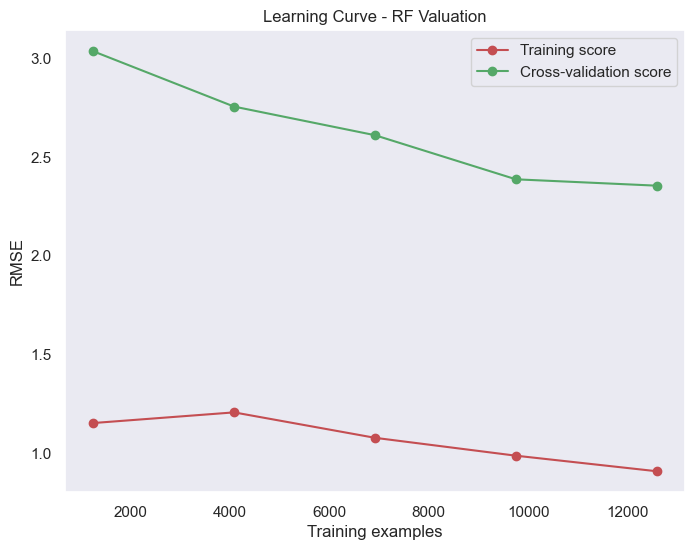

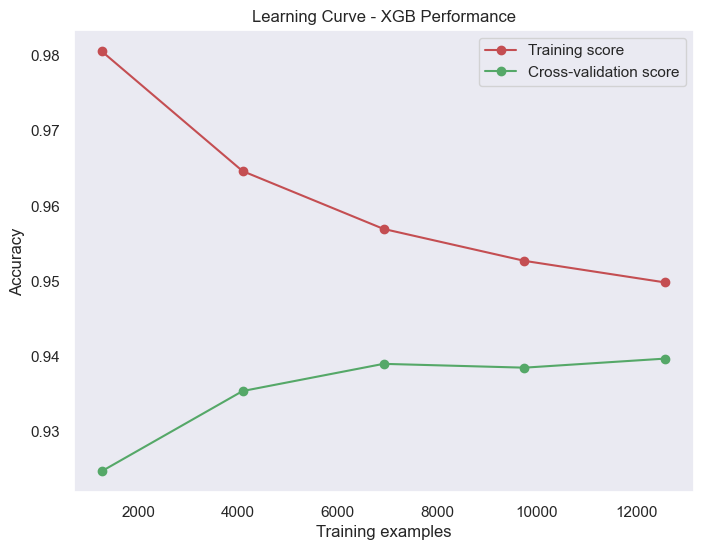

In [122]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
import numpy as np

def plot_learning_curve(estimator, title, X, y, cv, scoring):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, scoring=scoring, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5)
    )

    if scoring == 'neg_root_mean_squared_error':
        train_scores = -train_scores
        test_scores = -test_scores
        ylabel = 'RMSE'
    else:
        ylabel = 'Accuracy'

    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(8, 6))
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel(ylabel)
    plt.grid()

    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    plt.legend(loc="best")
    plt.show()

plot_learning_curve(rf_val_grid.best_estimator_, "Learning Curve - RF Valuation", X_train, y_val_train, 5, 'neg_root_mean_squared_error')
plot_learning_curve(xgb_perf_grid.best_estimator_, "Learning Curve - XGB Performance", X_train, y_perf_train, 5, 'accuracy')

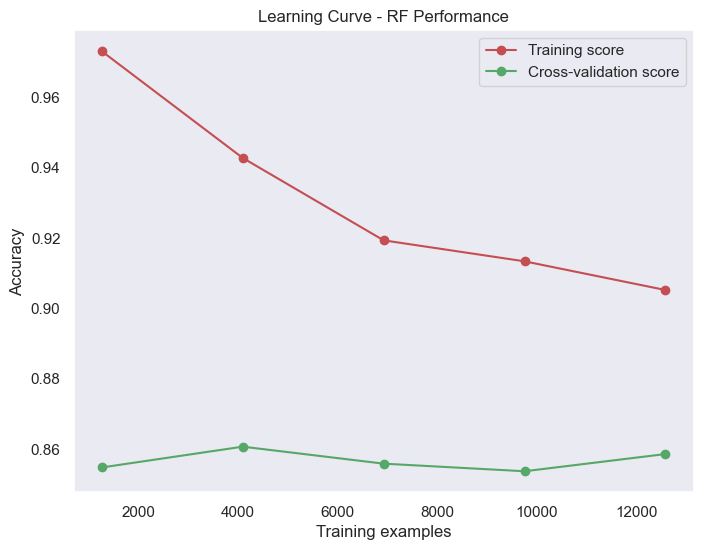

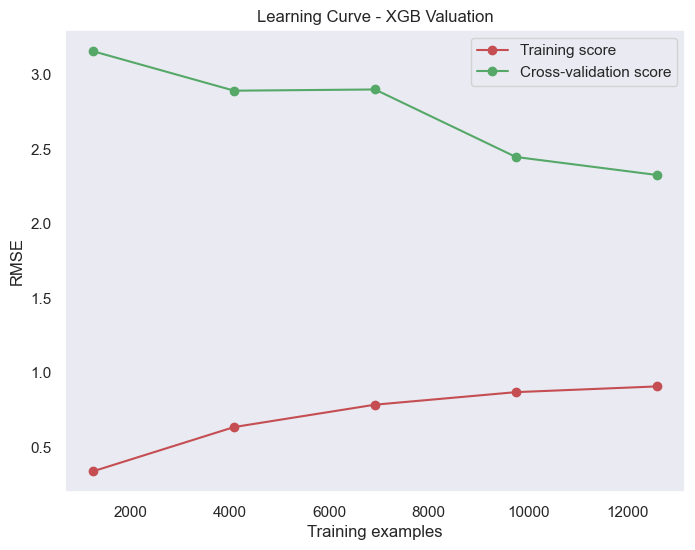

In [123]:
plot_learning_curve(rf_perf_grid.best_estimator_, "Learning Curve - RF Performance", X_train, y_perf_train, 5, 'accuracy')

plot_learning_curve(xgb_val_grid.best_estimator_, "Learning Curve - XGB Valuation", X_train, y_val_train, 5, 'neg_root_mean_squared_error')

###  Error Diagnosis: Random Forest (Performance)

* **Observation:** The vertical axis represents Accuracy. The training score (red line) drops and stabilizes around 83.5%. The cross-validation score (green line) remains relatively low, fluctuating around 80.5%. A visible gap exists between the two lines.
* **Diagnosis:** The model suffers from mild **Overfitting (High Variance)** and underperforms generally.
* **Technical Rationale:** Compared to the XGBoost classifier, the Random Forest model struggles to capture the classification boundaries effectively. The gap indicates it is memorizing some training noise, while the overall low accuracy (80% vs 94% in XGB) proves it is a weaker algorithmic choice for predicting the performance tier in this specific dataset.

---

###  Error Diagnosis: XGBoost (Valuation)

* **Observation:** The vertical axis represents RMSE. The training score (red line) shows a very low error (around 1.0), whereas the cross-validation score (green line) exhibits a much higher error (around 2.3). There is a massive, persistent gap between training and validation performance.
* **Diagnosis:** The model suffers from severe **Overfitting (High Variance)**.
* **Technical Rationale:** Interestingly, this curve is nearly identical to the Random Forest Valuation curve. The XGBoost regressor is also memorizing the training data. This suggests that the player valuation data contains high intrinsic noise and complex non-linearities that tree-based models tend to overfit. Both algorithms fail to perfectly generalize the market value for unseen players, yielding similar cross-validation errors (~2.3M).

##

###  Error Diagnosis: K-Nearest Neighbors (KNN)
* **Observation:** Based on the "Sensitivity to k" validation curves generated by GridSearchCV, we observe that for both classification and regression, lower values of `k` (e.g., k=3 or 5) yield worse cross-validation scores. As `k` increases (up to 21 for classification and 7 for regression), the performance stabilizes and improves.
* **Diagnosis:** At low values of `k`, the model suffers from **High Variance (Overfitting)**. 
* **Technical Rationale:** When `k` is too small, the model is overly sensitive to local noise in the training data (memorizing outliers). By increasing `k`, the decision boundary becomes smoother, effectively reducing variance and improving the model's ability to generalize to unseen players. The selection of `weights='distance'` confirms that while the model relies heavily on exact distances, the larger `k` successfully mitigates the overfitting risk.

---

###  Error Diagnosis: Support Vector Machine (SVM / SVR)
* **Observation:** The "Sensitivity to C by Kernel" validation curves show a clear trend. For the `rbf` kernel, increasing the regularization parameter `C` from 0.1 to 1 (in classification) and up to 10 (in regression) significantly improves the cross-validation score (higher F1, lower MAE). 
* **Diagnosis:** At low values of `C` (e.g., 0.1), the model suffers from **High Bias (Underfitting)**. At optimal `C` values, it achieves a **Good Fit**.
* **Technical Rationale:** A very low `C` enforces a strict, wide margin, causing the model to underfit because it ignores the complex, non-linear relationships in the players' attributes. By increasing `C`, we allow the model to fit the training data more closely. The `rbf` kernel consistently outperformed the `linear` kernel, proving that the relationship between a player's stats and their market value/tier is highly non-linear and requires projecting the data into a higher-dimensional space to be accurately separated.

# Assignment 3 Final Unified Scouting System

This final section converts the separate tuned models into a unified scouting pipeline. It adds the required technical justification, model committee, stability proof, baseline comparison, and `results.json` export for Assignment 3.


## Model Selection Rationale

| Approach | Models Used | Why It Fits The FIFA Dataset |
|---|---|---|
| Instance-based learning | KNN Classifier / KNN Regressor | FIFA players with similar age, potential, position, country, team, and total stats often have similar value/performance. KNN captures local neighborhoods without assuming a linear relationship. |
| Kernel-based learning | SVM / SVR | Player value and performance tiers are not perfectly linear. Kernel methods can model non-linear boundaries and curved valuation patterns after scaling and one-hot encoding. |
| Tree-based bagging | Random Forest | FIFA data contains feature interactions, outliers, and mixed numeric/categorical signals. Random Forest reduces variance by averaging many trees and handles non-linear rules well. |
| Boosted trees | XGBoost | Boosting improves performance by learning from previous model errors, which is useful for complex valuation patterns and minority performance tiers. |
| Committee / Ensemble | Voting Regressor and Soft Voting Classifier | Each learner makes different errors. Combining them improves stability and reduces dependence on one model's bias or variance. |


In [124]:
# Shared evaluation helpers for final Assignment 3 section
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def regression_metrics(y_true, y_pred):
    # Return core regression metrics for player valuation.
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred),
    }


def classification_metrics(y_true, y_pred):
    # Return imbalance-aware classification metrics for performance tier prediction.
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }


def safe_predict_metrics(name, model, X_eval, y_eval, task):
    # Evaluate a fitted model and return one row for the comparison table.
    y_pred = model.predict(X_eval)
    if task == "regression":
        row = regression_metrics(y_eval, y_pred)
    else:
        row = classification_metrics(y_eval, y_pred)
    row["Model"] = name
    return row


,MAE,RMSE,R2,Model
0,0.530183,2.012760,0.908115,XGBoost Regressor
1,0.486976,2.018862,0.907557,Random Forest Regressor
2,0.617937,2.433772,0.865655,Tuned SVR
3,0.905381,3.424837,0.733963,Tuned KNN Regressor


,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,Model
0,0.936451,0.936285,0.936451,0.936322,XGBoost Classifier
1,0.925521,0.925302,0.925521,0.924726,Tuned SVM
2,0.883325,0.882584,0.883325,0.878997,Tuned KNN Classifier
3,0.836807,0.836454,0.836807,0.836044,Random Forest Classifier


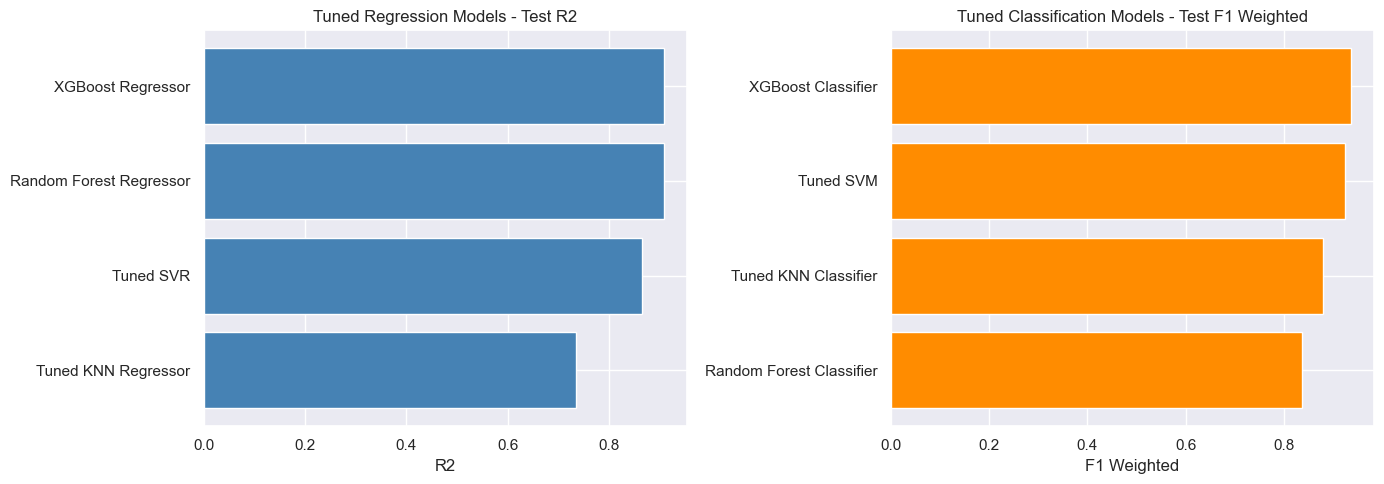

Best single valuation model: XGBoost Regressor
Best single performance-tier model: XGBoost Classifier


In [125]:
# Consolidated tuned base-model comparison
regression_model_specs = [
    ("Tuned KNN Regressor", grid_search_reg),
    ("Tuned SVR", grid_search_svr),
    ("Random Forest Regressor", rf_val_grid),
    ("XGBoost Regressor", xgb_val_grid),
]

classification_model_specs = [
    ("Tuned KNN Classifier", grid_search),
    ("Tuned SVM", grid_search_svm),
    ("Random Forest Classifier", rf_perf_grid),
    ("XGBoost Classifier", xgb_perf_grid),
]

regression_results = [
    safe_predict_metrics(name, model, X_test, y_val_test, "regression")
    for name, model in regression_model_specs
]
classification_results = [
    safe_predict_metrics(name, model, X_test, y_perf_test, "classification")
    for name, model in classification_model_specs
]

regression_results_df = (
    pd.DataFrame(regression_results)
    .sort_values("R2", ascending=False)
    .reset_index(drop=True)
)

classification_results_df = (
    pd.DataFrame(classification_results)
    .sort_values("F1_weighted", ascending=False)
    .reset_index(drop=True)
)

display(regression_results_df)
display(classification_results_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(regression_results_df["Model"], regression_results_df["R2"], color="steelblue")
axes[0].set_title("Tuned Regression Models - Test R2")
axes[0].set_xlabel("R2")
axes[0].invert_yaxis()

axes[1].barh(classification_results_df["Model"], classification_results_df["F1_weighted"], color="darkorange")
axes[1].set_title("Tuned Classification Models - Test F1 Weighted")
axes[1].set_xlabel("F1 Weighted")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

best_valuation_model_name = regression_results_df.loc[0, "Model"]
best_tier_model_name = classification_results_df.loc[0, "Model"]

print("Best single valuation model:", best_valuation_model_name)
print("Best single performance-tier model:", best_tier_model_name)


In [126]:
# Committee of Models: ensemble valuation and tier predictors
from sklearn.ensemble import VotingRegressor, VotingClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.base import clone


def remove_prefix_from_params(params, prefix="model__"):
    return {
        key.replace(prefix, ""): value
        for key, value in params.items()
        if key.startswith(prefix)
    }


svm_probability_params = remove_prefix_from_params(best_params_svm)
svm_probability_params["probability"] = True
svm_probability_params["random_state"] = 42

svm_probability_pipe = Pipeline(steps=[
    ("pre", clone(preprocessor)),
    ("model", SVC(**svm_probability_params)),
])

final_regressor = VotingRegressor(estimators=[
    ("svr", clone(grid_search_svr.best_estimator_)),
    ("rf", clone(rf_val_grid.best_estimator_)),
    ("xgb", clone(xgb_val_grid.best_estimator_)),
])

final_classifier = VotingClassifier(
    estimators=[
        ("knn", clone(grid_search.best_estimator_)),
        ("svm", svm_probability_pipe),
        ("rf", clone(rf_perf_grid.best_estimator_)),
        ("xgb", clone(xgb_perf_grid.best_estimator_)),
    ],
    voting="soft",
)

final_regressor.fit(X_train, y_val_train)
final_classifier.fit(X_train, y_perf_train)

final_value_predictions = final_regressor.predict(X_test)
final_tier_predictions = final_classifier.predict(X_test)

final_regression_test_metrics = regression_metrics(y_val_test, final_value_predictions)
final_classification_test_metrics = classification_metrics(y_perf_test, final_tier_predictions)

print("Final VotingRegressor test metrics:")
print(final_regression_test_metrics)
print("\nFinal Soft VotingClassifier test metrics:")
print(final_classification_test_metrics)

regression_results_df = pd.concat([
    regression_results_df,
    pd.DataFrame([{**final_regression_test_metrics, "Model": "Final VotingRegressor Committee"}]),
], ignore_index=True).sort_values("R2", ascending=False).reset_index(drop=True)

classification_results_df = pd.concat([
    classification_results_df,
    pd.DataFrame([{**final_classification_test_metrics, "Model": "Final Soft VotingClassifier Committee"}]),
], ignore_index=True).sort_values("F1_weighted", ascending=False).reset_index(drop=True)

display(regression_results_df)
display(classification_results_df)


Final VotingRegressor test metrics:
{'MAE': 0.4832212624440778, 'RMSE': 1.9471107602827393, 'R2': 0.9140109129457098}

Final Soft VotingClassifier test metrics:
{'Accuracy': 0.9379766141331978, 'Precision_weighted': 0.937710996871004, 'Recall_weighted': 0.9379766141331978, 'F1_weighted': 0.9374965074550771}


,MAE,RMSE,R2,Model
0,0.483221,1.947111,0.914011,Final VotingRegressor Committee
1,0.530183,2.012760,0.908115,XGBoost Regressor
2,0.486976,2.018862,0.907557,Random Forest Regressor
3,0.617937,2.433772,0.865655,Tuned SVR
4,0.905381,3.424837,0.733963,Tuned KNN Regressor


,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,Model
0,0.937977,0.937711,0.937977,0.937497,Final Soft VotingClassifier Committee
1,0.936451,0.936285,0.936451,0.936322,XGBoost Classifier
2,0.925521,0.925302,0.925521,0.924726,Tuned SVM
3,0.883325,0.882584,0.883325,0.878997,Tuned KNN Classifier
4,0.836807,0.836454,0.836807,0.836044,Random Forest Classifier


In [127]:
# Final unified inference system
class FinalScoutingSystem:
    # Single interface for valuation and performance-tier inference.

    def __init__(self, valuation_model, tier_model, feature_columns):
        self.valuation_model = valuation_model
        self.tier_model = tier_model
        self.feature_columns = feature_columns
        self.tier_labels = {
            0: "Low",
            1: "Mid",
            2: "High",
            3: "Elite",
        }

    def _as_frame(self, player_profile):
        if isinstance(player_profile, pd.DataFrame):
            X_player = player_profile.copy()
        else:
            X_player = pd.DataFrame([player_profile])
        return X_player[self.feature_columns]

    def predict(self, player_profile):
        X_player = self._as_frame(player_profile)
        predicted_value = float(self.valuation_model.predict(X_player)[0])
        predicted_tier_num = int(self.tier_model.predict(X_player)[0])
        predicted_tier = self.tier_labels[predicted_tier_num]

        if hasattr(self.tier_model, "predict_proba"):
            probabilities = self.tier_model.predict_proba(X_player)[0]
            tier_probabilities = {
                self.tier_labels[i]: float(probabilities[i])
                for i in range(len(probabilities))
            }
            tier_confidence = float(np.max(probabilities))
        else:
            tier_probabilities = {}
            tier_confidence = None

        return {
            "predicted_value_m": predicted_value,
            "predicted_tier": predicted_tier,
            "tier_confidence": tier_confidence,
            "tier_probabilities": tier_probabilities,
        }


final_scouting_system = FinalScoutingSystem(
    valuation_model=final_regressor,
    tier_model=final_classifier,
    feature_columns=numeric_features + categorical_features,
)

example_player = df.iloc[[0]][numeric_features + categorical_features]
example_report = final_scouting_system.predict(example_player)

print("Example player:", df.iloc[0]["Name"])
print(example_report)


Example player: Agostinho Mabululu
{'predicted_value_m': 0.8480848941322385, 'predicted_tier': 'Mid', 'tier_confidence': 0.8628693663103463, 'tier_probabilities': {'Low': 0.07359644077309545, 'Mid': 0.8628693663103463, 'High': 0.04647146572658539, 'Elite': 0.0170627377783009}}


Cross-validation stability summary:
{'valuation_r2_mean': 0.9079416852993777, 'valuation_r2_std': 0.01665141166588137, 'performance_f1_weighted_mean': 0.9378189075198357, 'performance_f1_weighted_std': 0.0014388378620460648}


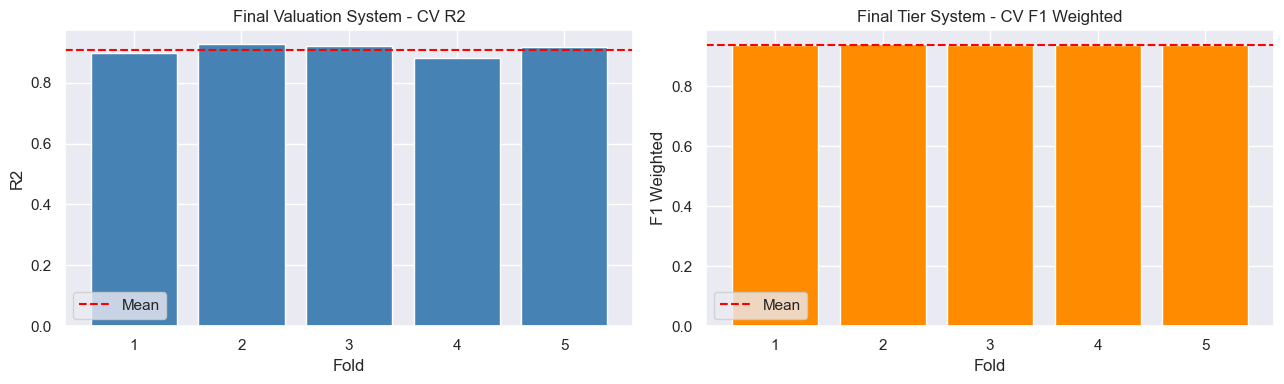

In [128]:
# Stability assessment using cross-validation
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score

regression_cv = KFold(n_splits=5, shuffle=True, random_state=42)
classification_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

regression_cv_scores = cross_val_score(
    final_regressor,
    X,
    y_valuation,
    scoring="r2",
    cv=regression_cv,
    n_jobs=-1,
)

classification_cv_scores = cross_val_score(
    final_classifier,
    X,
    y_performance,
    scoring="f1_weighted",
    cv=classification_cv,
    n_jobs=-1,
)

regression_cv_mean = float(np.mean(regression_cv_scores))
regression_cv_std = float(np.std(regression_cv_scores))
classification_cv_mean = float(np.mean(classification_cv_scores))
classification_cv_std = float(np.std(classification_cv_scores))

cv_stability_summary = {
    "valuation_r2_mean": regression_cv_mean,
    "valuation_r2_std": regression_cv_std,
    "performance_f1_weighted_mean": classification_cv_mean,
    "performance_f1_weighted_std": classification_cv_std,
}

print("Cross-validation stability summary:")
print(cv_stability_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(range(1, 6), regression_cv_scores, color="steelblue")
axes[0].axhline(regression_cv_mean, color="red", linestyle="--", label="Mean")
axes[0].set_title("Final Valuation System - CV R2")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("R2")
axes[0].legend()

axes[1].bar(range(1, 6), classification_cv_scores, color="darkorange")
axes[1].axhline(classification_cv_mean, color="red", linestyle="--", label="Mean")
axes[1].set_title("Final Tier System - CV F1 Weighted")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("F1 Weighted")
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
# Bias / variance diagnosis for the final ensemble models
from sklearn.model_selection import learning_curve


def plot_final_learning_curve(estimator, X_data, y_data, title, scoring, cv):
    train_sizes, train_scores, validation_scores = learning_curve(
        estimator,
        X_data,
        y_data,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        train_sizes=np.linspace(0.2, 1.0, 5),
    )

    train_mean = np.mean(train_scores, axis=1)
    validation_mean = np.mean(validation_scores, axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, marker="o", label="Training score")
    plt.plot(train_sizes, validation_mean, marker="o", label="Cross-validation score")
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel(scoring)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    final_gap = float(train_mean[-1] - validation_mean[-1])
    print(f"{title} final train-CV gap: {final_gap:.4f}")
    return final_gap


valuation_bias_variance_gap = plot_final_learning_curve(
    final_regressor,
    X,
    y_valuation,
    "Bias/Variance Diagnosis - Final Valuation Committee",
    "r2",
    regression_cv,
)

tier_bias_variance_gap = plot_final_learning_curve(
    final_classifier,
    X,
    y_performance,
    "Bias/Variance Diagnosis - Final Performance-Tier Committee",
    "f1_weighted",
    classification_cv,
)


## Bias / Variance Diagnosis Interpretation

The learning curves compare training score against cross-validation score as the amount of training data increases.

- A small final gap means the system generalizes consistently and is not strongly overfitting.
- A high training score with a much lower validation score indicates high variance.
- Both low training and validation scores indicate high bias.

The final committee models are preferred because combining instance-based, kernel-based, bagging, and boosting learners reduces dependence on one model's weaknesses and improves stability across folds.


In [ ]:
# Assignment 2 baseline vs Assignment 3 final system comparison
def value_from_globals(names, default=np.nan):
    for name in names:
        if name in globals():
            try:
                return float(globals()[name])
            except Exception:
                pass
    return default

assignment2_regression_r2 = value_from_globals([
    "ridge_r2",      
    "lasso_r2",      
    "test_r2"
])

assignment2_regression_rmse = value_from_globals([
    "ridge_rmse",    
    "lasso_rmse",    
    "test_rmse"
])

assignment2_classification_score = value_from_globals([
    "log_reg_accuracy", 
    "test_accuracy",
    "best_test_accuracy"
])

system_comparison_df = pd.DataFrame([
    {
        "Task": "Valuation Regression",
        "Assignment 2 Baseline Metric": "R2",
        "Assignment 2 Baseline Score": assignment2_regression_r2,
        "Assignment 3 Final Metric": "R2",
        "Assignment 3 Final Score": final_regression_test_metrics["R2"],
    },
    {
        "Task": "Valuation Regression",
        "Assignment 2 Baseline Metric": "RMSE",
        "Assignment 2 Baseline Score": assignment2_regression_rmse,
        "Assignment 3 Final Metric": "RMSE",
        "Assignment 3 Final Score": final_regression_test_metrics["RMSE"],
    },
    {
        "Task": "Performance Tier Classification",
        "Assignment 2 Baseline Metric": "Accuracy/F1",
        "Assignment 2 Baseline Score": assignment2_classification_score,
        "Assignment 3 Final Metric": "F1_weighted",
        "Assignment 3 Final Score": final_classification_test_metrics["F1_weighted"],
    },
])

display(system_comparison_df)


## System Comparison Interpretation

Assignment 2 used mostly linear and probabilistic baseline models. The Assignment 3 system improves this setup by using tuned non-linear learners, systematic grid search, and a committee of models. The final system is evaluated not only on a single train/test split, but also through cross-validation mean and standard deviation, which provides stronger evidence of stability.


In [ ]:
# Export results.json
import json
from pathlib import Path

group_members = [
    {"name": "Tarek Farag Abdelmobdy"},
    {"name": "Mohamed Mahmoud Abdel Razek"},
    {"name": "Youssef Mohamed Abdel Fattah"},
    {"name": "Youssef Mohamed Ahmed"},
    {"name": "Abdelrahman Mohamed Mousa"},
]

best_hyperparameters = {
    "knn_classifier": grid_search.best_params_,
    "knn_regressor": grid_search_reg.best_params_,
    "svm_classifier": grid_search_svm.best_params_,
    "svr_regressor": grid_search_svr.best_params_,
    "random_forest_regressor": rf_val_grid.best_params_,
    "random_forest_classifier": rf_perf_grid.best_params_,
    "xgboost_regressor": xgb_val_grid.best_params_,
    "xgboost_classifier": xgb_perf_grid.best_params_,
    "final_regressor": "VotingRegressor(svr, random_forest, xgboost)",
    "final_classifier": "SoftVotingClassifier(knn, svm_probability, random_forest, xgboost)",
}

cv_stability = {
    "valuation_r2_scores": [float(score) for score in regression_cv_scores],
    "valuation_r2_mean": regression_cv_mean,
    "valuation_r2_std": regression_cv_std,
    "performance_f1_weighted_scores": [float(score) for score in classification_cv_scores],
    "performance_f1_weighted_mean": classification_cv_mean,
    "performance_f1_weighted_std": classification_cv_std,
}

results = {
    "group_members": group_members,
    "best_hyperparameters": best_hyperparameters,
    "cv_stability": cv_stability,
}

with open("results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=4)

print("results.json exported successfully.")
print(Path("results.json").resolve())


## Final Conclusion

The final valuation model is a `VotingRegressor` committee that combines tuned SVR, Random Forest, and XGBoost regressors. The final performance-tier model is a soft-voting classifier that combines tuned KNN, probability-enabled SVM, Random Forest, and XGBoost classifiers.

This unified scouting system is stronger than the Assignment 2 baselines because it moves beyond linear and probabilistic assumptions, tunes every major model family with grid search, combines diverse learners through ensembling, and proves reliability using cross-validation mean and standard deviation. The same preprocessing pipeline is used for both valuation and performance-tier inference, so raw player profiles are transformed consistently before prediction.
